In [7]:
import pandas as pd
import numpy as np
import utils
import re
import glob
import os
import tidytcells as tt
from typing import Literal
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import defaultdict
import itertools
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns
from scipy import stats
import pickle
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap

In [20]:
metadata = pd.read_csv("/mnt/d/TCRdataset/covid_GSE196456/metadata.csv")
metadata = metadata.dropna(subset=['barcode','TRAV','TRBV','TRAJ','TRBJ','cdr3A','cdr3B'])
metadata['patient_status'] = metadata.Patient.str.cat(metadata.Age_status)
metadata['TRAV'] = metadata['TRAV'].map(tt.tr.standardize)
metadata['TRBV'] = metadata['TRBV'].map(tt.tr.standardize)
metadata['TRAJ'] = metadata['TRAJ'].map(tt.tr.standardize)
metadata['TRBJ'] = metadata['TRBJ'].map(tt.tr.standardize)
print(metadata.shape)

(234006, 34)


# Analysis


In [2]:
from itertools import combinations
import scipy.stats as stats
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def perform_statistical_tests(df_plot, unique_samples, test_direction='two-sided', adjust_pvalues=True, adjust_method="FDR"):
    """
    Perform pairwise statistical comparisons between all samples
    
    Parameters:
    test_direction: 'greater', 'less', or 'two-sided'
        - 'greater': Test if Sample1 > Sample2 (Sample1 has higher MI values)
        - 'less': Test if Sample1 < Sample2 (Sample1 has lower MI values)
        - 'two-sided': Test if Sample1 ≠ Sample2 (any difference)
    """
    from statsmodels.stats.multitest import multipletests
    
    all_results = []
    
    # Get MI values for each sample
    sample_data = {}
    for sample in unique_samples:
        sample_data[sample] = df_plot[df_plot['Sample_ID'] == sample]['MI_Value'].values
    
    # Perform pairwise comparisons
    total_comparisons = 0
    for sample1, sample2 in combinations(unique_samples, 2):
        total_comparisons += 1
        data1 = sample_data[sample1]
        data2 = sample_data[sample2]
        
        # Calculate all three types of tests
        _, p_greater = stats.mannwhitneyu(data1, data2, alternative='greater')
        _, p_less = stats.mannwhitneyu(data1, data2, alternative='less')
        _, p_two_sided = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Select p-value based on test direction
        if test_direction == 'two-sided':
            p_raw = p_two_sided
        elif test_direction == 'greater':
            p_raw = p_greater
        elif test_direction == 'less':
            p_raw = p_less
        else:
            p_raw = p_two_sided
        
        all_results.append({
            'Sample1': sample1,
            'Sample2': sample2,
            'Sample1_Mean': np.mean(data1),
            'Sample2_Mean': np.mean(data2),
            'Mean_Difference': np.mean(data1) - np.mean(data2),
            'P_Value_Raw': p_raw,
            'P_Value_less': p_less,
            'P_Value_greater': p_greater,
            'P_Value_Two_Sided': p_two_sided,
            'N1': len(data1), 
            'N2': len(data2),
            'Test_Direction': test_direction
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(all_results)
    
    if adjust_pvalues:
        # Apply multiple testing correction to the main p-value
        p_values = results_df['P_Value_Raw'].values 
        
        # Benjamini-Hochberg (FDR) - less conservative than Bonferroni
        rejected_fdr, p_adjusted_fdr, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Bonferroni - more conservative
        rejected_bonf, p_adjusted_bonf, _, _ = multipletests(p_values, method='bonferroni')
        
        results_df['P_Value_FDR'] = p_adjusted_fdr
        results_df['P_Value_Bonferroni'] = p_adjusted_bonf
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        results_df['Significant_FDR'] = rejected_fdr
        results_df['Significant_Bonferroni'] = rejected_bonf
        
        # Filter significant results (you can choose which method to use)
        if adjust_method == "FDR":
            found_significant = results_df[results_df['Significant_FDR']].copy()
        else:
            found_significant = results_df[results_df['Significant_Bonferroni']].copy()
        
    else:
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        found_significant = results_df[results_df['Significant_Raw']].copy()
        
    return results_df, found_significant

def create_pvalue_matrix(results_df, unique_samples, p_value_col='P_Value_Bonferroni'):
    """
    Create a symmetric p-value matrix from pairwise comparison results
    """
    n_samples = len(unique_samples)
    p_matrix = np.ones((n_samples, n_samples))  # Initialize with 1s (diagonal)
    
    # Create sample index mapping
    sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}
    
    # Fill the matrix
    for _, row in results_df.iterrows():
        i = sample_to_idx[row['Sample1']]
        j = sample_to_idx[row['Sample2']]
        p_val = row[p_value_col]
        
        # Fill both symmetric positions
        p_matrix[i, j] = p_val
        p_matrix[j, i] = p_val
    
    return p_matrix

def create_mi_plot(mi_path, samples_path, save_dir=None, select_features=None):
    """
    Create bar plots with error bars and combined p-value heatmaps for all feature pairs.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    # Define fixed sample order
    desired_sample_order = [
        'ICU_Adult_Acute', 
        'ICU_Adult_Convalescent', 
        'Non_ICU_Adult_Acute',
        'Non_ICU_Adult_Convalescent', 
        'Non_ICU_Kid_Acute',
        'Non_ICU_Kid_Convalescent'
    ]
    
    # Define category function
    def category_func(sample_id):
        if 'Non_ICU_Adult' in sample_id:
            return 'Non-ICU Adults'
        elif 'ICU_Adult' in sample_id:
            return 'ICU Adults'
        elif 'Kid' in sample_id:
            return 'Children'
        else:
            return 'Unknown'
    
    # Define color palettes
    color_dict = {
        'Non-ICU Adults': '#2E8B57',    # Sea Green
        'ICU Adults': '#DC143C',        # Crimson
        'Children': '#4169E1'           # Royal Blue
    }
    
    legend_title = 'ICU Categories'
    
    # Storage for all feature results
    all_feature_results = {}
    all_feature_stats = {}
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis - use fixed order
        sample_ids = [sample for sample in desired_sample_order if sample in data_dict.keys()]
    
        # Prepare plot data for statistical tests
        plot_data = []
        for sample_idx, sample_id in enumerate(sample_ids):
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    original_sample_idx = list(data_dict.keys()).index(sample_id)
                    if original_sample_idx < len(mi_values_array):
                        plot_data.append({
                            'Sample_ID': sample_id,
                            'MI_Value': mi_values_array[original_sample_idx]
                        })
        
        df_plot_limited = pd.DataFrame(plot_data)
        
        # Calculate statistics for each sample (for bar plot)
        stats_data = []
        for sample_id in sample_ids:
            values = []
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    original_sample_idx = list(data_dict.keys()).index(sample_id)
                    if original_sample_idx < len(mi_values_array):
                        values.append(mi_values_array[original_sample_idx])
            
            if values:
                stats_data.append({
                    'Sample_ID': sample_id,
                    'Mean': np.mean(values),
                    'Std': np.std(values),
                    'SE': np.std(values) / np.sqrt(len(values)),
                    'Min': np.min(values),
                    'Max': np.max(values),
                    'Category': category_func(sample_id),
                    'N_Points': len(values)
                })
        
        df_stats = pd.DataFrame(stats_data)
        
        if df_stats.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        # Store results for combined heatmap
        all_feature_stats[(feature1, feature2)] = df_stats
        
        # Perform statistical tests
        if not df_plot_limited.empty:
            results_df, found_significant = perform_statistical_tests(
                df_plot_limited, sample_ids, 
                test_direction='one-sided',
                adjust_pvalues=True,
                adjust_method='Bonferroni'
            )
            if select_features is None or (feature1, feature2) in select_features:
                all_feature_results[(feature1, feature2)] = results_df
        
        # Create individual bar plot
        plt.figure(figsize=(8, 6))
        
        x_positions = np.arange(len(df_stats))
        bar_width = 0.3
        
        # Create bars and collect them for legend
        bars_by_category = {}
        for i, row in df_stats.iterrows():
            category = row['Category']
            color = color_dict.get(category, '#808080')
            
            # Create bar
            bar = plt.bar(i, row['Mean'], bar_width, 
                         color=color, alpha=0.7, 
                         edgecolor='black', linewidth=0.5)
            
            # Store bar for legend (only one per category)
            if category not in bars_by_category:
                bars_by_category[category] = bar[0]
            
            # Add error bars (using standard deviation)
            plt.errorbar(i, row['Mean'], yerr=row['Std'], 
                        color='black', capsize=5, capthick=0.5, 
                        linewidth=1.5, alpha=0.8)
            
            # Add value labels on top of bars
            plt.text(i, row['Mean'] + row['Std'] + max(df_stats['Mean']) * 0.02, 
                    f'{row["Mean"]:.3f}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Customize the plot
        plt.xlabel('Sample ID', fontsize=12, fontweight='bold')
        plt.ylabel('NMI Value', fontsize=12, fontweight='bold')
        plt.title(f'{feature1} vs {feature2}\n(Error bars = Standard Deviation)', 
                 fontsize=14, fontweight='bold')
        
        # Set x-axis labels
        plt.xticks(x_positions, df_stats['Sample_ID'], rotation=45, ha='right', fontsize=10)
        
        # Add grid for better readability
        plt.grid(True, alpha=0.3, axis='y', linestyle='--')
        
        # Create legend using collected bars
        legend_handles = []
        legend_labels = []
        for category in sorted(bars_by_category.keys()):
            legend_handles.append(bars_by_category[category])
            legend_labels.append(category)
        
        plt.legend(legend_handles, legend_labels, 
                  title=legend_title, loc='upper right', 
                  bbox_to_anchor=(1.15, 1), fontsize=10)
        
        # Save individual bar plot
        if save_dir:
            if select_features is None or (feature1, feature2) in select_features:
                save_path = os.path.join(save_dir, f'MI_barplot_{feature1}_vs_{feature2}.pdf')
                plt.savefig(save_path, transparent=True, bbox_inches='tight', dpi=300)
                print(f"Bar plot saved to: {save_path}")
        
        plt.tight_layout()
    
    # Create combined heatmap figure for all feature pairs
    if all_feature_results:
        n_features = len(all_feature_results)
        n_cols = min(3, n_features)  # Max 3 columns
        n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        
        # Handle single subplot case
        if n_features == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()
        
        for idx, ((feature1, feature2), results_df) in enumerate(all_feature_results.items()):
            ax = axes[idx] if n_features > 1 else axes[0]
            
            # Get sample order for this feature
            sample_ids = [sample for sample in desired_sample_order if sample in data_dict.keys()]
            
            # Create p-value matrix
            p_matrix = create_pvalue_matrix(results_df, sample_ids, 'P_Value_Bonferroni')
            
            # Create heatmap
            im = ax.imshow(p_matrix, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=0.1)
            
            # Set ticks and labels
            ax.set_xticks(range(len(sample_ids)))
            ax.set_yticks(range(len(sample_ids)))
            ax.set_xticklabels([s.replace('_', '\n') for s in sample_ids], rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels([s.replace('_', '\n') for s in sample_ids], fontsize=8)
            
            # Add text annotations
            for i in range(len(sample_ids)):
                for j in range(len(sample_ids)):
                    if i != j:  # Don't annotate diagonal
                        text_color = 'white' if p_matrix[i, j] < 0.05 else 'black'
                        ax.text(j, i, f'{p_matrix[i, j]:.3f}', 
                               ha='center', va='center', color=text_color, fontsize=7, fontweight='bold')
            
            ax.set_title(f'{feature1} vs {feature2}\n(Bonferroni corrected p-values)', fontsize=10, fontweight='bold')
            
            # Add colorbar for each subplot
            cbar = plt.colorbar(im, ax=ax, shrink=0.8)
            cbar.set_label('P-value', fontsize=8)
        
        # Hide unused subplots
        for idx in range(n_features, len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle('P-value Heatmaps for All Feature Pairs\n(Mann-Whitney U test, Bonferroni correction)', 
                     fontsize=16, fontweight='bold')
        
        # Save combined heatmap
        if save_dir:
            save_path = os.path.join(save_dir, 'MI_pvalue_heatmaps_combined.pdf')
            plt.savefig(save_path, transparent=True, bbox_inches='tight', dpi=300)
            print(f"Combined p-value heatmaps saved to: {save_path}")
    

In [ ]:
from itertools import combinations
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def perform_statistical_tests(df_plot, unique_samples, test_direction='two-sided', adjust_pvalues=True, adjust_method="FDR"):
    """
    Perform pairwise statistical comparisons between all samples
    
    Parameters:
    test_direction: 'greater', 'less', or 'two-sided'
        - 'greater': Test if Sample1 > Sample2 (Sample1 has higher MI values)
        - 'less': Test if Sample1 < Sample2 (Sample1 has lower MI values)
        - 'two-sided': Test if Sample1 ≠ Sample2 (any difference)
    """
    from statsmodels.stats.multitest import multipletests
    
    all_results = []
    
    # Get MI values for each sample
    sample_data = {}
    for sample in unique_samples:
        sample_data[sample] = df_plot[df_plot['Sample_ID'] == sample]['MI_Value'].values
    
    # Perform pairwise comparisons
    total_comparisons = 0
    for sample1, sample2 in combinations(unique_samples, 2):
        total_comparisons += 1
        data1 = sample_data[sample1]
        data2 = sample_data[sample2]
        
        # Calculate all three types of tests
        _, p_greater = stats.mannwhitneyu(data1, data2, alternative='greater')
        _, p_less = stats.mannwhitneyu(data1, data2, alternative='less')
        _, p_two_sided = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Select p-value based on test direction
        if test_direction == 'two-sided':
            p_raw = p_two_sided
        elif test_direction == 'greater':
            p_raw = p_greater
        elif test_direction == 'less':
            p_raw = p_less
        else:
            p_raw = p_two_sided
        
        all_results.append({
            'Sample1': sample1,
            'Sample2': sample2,
            'Sample1_Mean': np.mean(data1),
            'Sample2_Mean': np.mean(data2),
            'Mean_Difference': np.mean(data1) - np.mean(data2),
            'P_Value_Raw': p_raw,
            'P_Value_less': p_less,
            'P_Value_greater': p_greater,
            'P_Value_Two_Sided': p_two_sided,
            'N1': len(data1), 
            'N2': len(data2),
            'Test_Direction': test_direction
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(all_results)
    
    if adjust_pvalues:
        # Apply multiple testing correction to the main p-value
        p_values = results_df['P_Value_Raw'].values 
        
        # Benjamini-Hochberg (FDR) - less conservative than Bonferroni
        rejected_fdr, p_adjusted_fdr, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Bonferroni - more conservative
        rejected_bonf, p_adjusted_bonf, _, _ = multipletests(p_values, method='bonferroni')
        
        results_df['P_Value_FDR'] = p_adjusted_fdr
        results_df['P_Value_Bonferroni'] = p_adjusted_bonf
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        results_df['Significant_FDR'] = rejected_fdr
        results_df['Significant_Bonferroni'] = rejected_bonf
        
        # Filter significant results (you can choose which method to use)
        if adjust_method == "FDR":
            found_significant = results_df[results_df['Significant_FDR']].copy()
        else:
            found_significant = results_df[results_df['Significant_Bonferroni']].copy()
        
    else:
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        found_significant = results_df[results_df['Significant_Raw']].copy()
        
    return results_df, found_significant

def create_pvalue_matrix(results_df, unique_samples, p_value_col='P_Value_Bonferroni'):
    """
    Create a symmetric p-value matrix from pairwise comparison results
    """
    n_samples = len(unique_samples)
    p_matrix = np.ones((n_samples, n_samples))  # Initialize with 1s (diagonal)
    
    # Create sample index mapping
    sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}
    
    # Fill the matrix
    for _, row in results_df.iterrows():
        i = sample_to_idx[row['Sample1']]
        j = sample_to_idx[row['Sample2']]
        p_val = row[p_value_col]
        
        # Fill both symmetric positions
        p_matrix[i, j] = p_val
        p_matrix[j, i] = p_val
    
    return p_matrix

def create_individual_barplot(df_stats, feature1, feature2, color_dict, legend_title, save_dir=None):
    """
    Create individual bar plot and save it
    """
    # Create figure without showing it
    fig, ax = plt.subplots(figsize=(8, 6))
    
    x_positions = np.arange(len(df_stats))
    bar_width = 0.3
    
    # Create bars and collect them for legend
    bars_by_category = {}
    for i, row in df_stats.iterrows():
        category = row['Category']
        color = color_dict.get(category, '#808080')
        
        # Create bar
        bar = ax.bar(i, row['Mean'], bar_width, 
                     color=color, alpha=0.7, 
                     edgecolor='black', linewidth=0.5)
        
        # Store bar for legend (only one per category)
        if category not in bars_by_category:
            bars_by_category[category] = bar[0]
        
        # Add error bars (using standard deviation)
        ax.errorbar(i, row['Mean'], yerr=row['Std'], 
                    color='black', capsize=5, capthick=0.5, 
                    linewidth=1.5, alpha=0.8)
        
        # Add value labels on top of bars
        ax.text(i, row['Mean'] + row['Std'] + max(df_stats['Mean']) * 0.02, 
                f'{row["Mean"]:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Customize the plot
    #ax.set_xlabel('Sample ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('NMI Value', fontsize=12, fontweight='bold')
    ax.set_title(f'{feature1} vs {feature2}\n(Error bars = Standard Deviation)', 
                 fontsize=14, fontweight='bold')
    
    # Set x-axis labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(df_stats['Sample_ID'], rotation=45, ha='right', fontsize=10)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Create legend using collected bars
    legend_handles = []
    legend_labels = []
    for category in sorted(bars_by_category.keys()):
        legend_handles.append(bars_by_category[category])
        legend_labels.append(category)
    
    ax.legend(legend_handles, legend_labels, 
              title=legend_title, loc='upper right', 
              bbox_to_anchor=(1.15, 1), fontsize=10)
    
    plt.tight_layout()
    
    # Save individual bar plot
    if save_dir:
        save_path = os.path.join(save_dir, f'MI_barplot_{feature1}_vs_{feature2}.pdf')
        plt.savefig(save_path, transparent=True, bbox_inches='tight', dpi=300)
        print(f"Bar plot saved to: {save_path}")
    
    # Close the figure to prevent it from showing
    plt.close(fig)
    
    return fig

def create_individual_heatmap(results_df, sample_ids, feature1, feature2, save_dir=None):
    """
    Create individual heatmap and save it
    """
    # Create figure without showing it
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Create p-value matrix
    p_matrix = create_pvalue_matrix(results_df, sample_ids, 'P_Value_Bonferroni')
    
    # Create heatmap
    im = ax.imshow(p_matrix, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=0.1)
    
    # Set ticks and labels
    ax.set_xticks(range(len(sample_ids)))
    ax.set_yticks(range(len(sample_ids)))
    ax.set_xticklabels([s.replace('_', '\n') for s in sample_ids], rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels([s.replace('_', '\n') for s in sample_ids], fontsize=8)
    
    # Add text annotations
    for i in range(len(sample_ids)):
        for j in range(len(sample_ids)):
            if i != j:  # Don't annotate diagonal
                text_color = 'white' if p_matrix[i, j] < 0.05 else 'black'
                ax.text(j, i, f'{p_matrix[i, j]:.3f}', 
                       ha='center', va='center', color=text_color, fontsize=7, fontweight='bold')
    
    ax.set_title(f'{feature1} vs {feature2}', fontsize=10, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('P-value', fontsize=8)
    
    plt.tight_layout()
    
    # Save individual heatmap
    if save_dir:
        save_path = os.path.join(save_dir, f'MI_heatmap_{feature1}_vs_{feature2}.pdf')
        plt.savefig(save_path, transparent=True, bbox_inches='tight', dpi=300)
        print(f"Heatmap saved to: {save_path}")
    
    # Close the figure to prevent it from showing
    plt.close(fig)
    
    return fig

def create_mi_plot(mi_path, samples_path, save_dir=None, select_features=None):
    """
    Create bar plots with error bars and combined p-value heatmaps for all feature pairs.
    Only show the combined figures in Jupyter notebook.
    """
    import seaborn as sns
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    # Define fixed sample order
    desired_sample_order = [
        'ICU_Adult_Acute', 
        'ICU_Adult_Convalescent', 
        'Non_ICU_Adult_Acute',
        'Non_ICU_Adult_Convalescent', 
        'Non_ICU_Kid_Acute',
        'Non_ICU_Kid_Convalescent'
    ]
    
    # Define category function
    def category_func(sample_id):
        if 'Non_ICU_Adult' in sample_id:
            return 'Non-ICU Adults'
        elif 'ICU_Adult' in sample_id:
            return 'ICU Adults'
        elif 'Kid' in sample_id:
            return 'Children'
        else:
            return 'Unknown'
    
    # Define color palettes
    color_dict = {
        'Non-ICU Adults': '#2E8B57',    # Sea Green
        'ICU Adults': '#DC143C',        # Crimson
        'Children': '#4169E1'           # Royal Blue
    }
    
    legend_title = 'ICU Categories'
    
    # Storage for all feature results
    all_feature_results = {}
    all_feature_stats = {}
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis - use fixed order
        sample_ids = [sample for sample in desired_sample_order if sample in data_dict.keys()]
    
        # Prepare plot data for statistical tests
        plot_data = []
        for sample_idx, sample_id in enumerate(sample_ids):
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    original_sample_idx = list(data_dict.keys()).index(sample_id)
                    if original_sample_idx < len(mi_values_array):
                        plot_data.append({
                            'Sample_ID': sample_id,
                            'MI_Value': mi_values_array[sample_id]
                        })
        
        df_plot_limited = pd.DataFrame(plot_data)
        
        # Calculate statistics for each sample (for bar plot)
        stats_data = []
        for sample_id in sample_ids:
            values = []
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    original_sample_idx = list(data_dict.keys()).index(sample_id)
                    if original_sample_idx < len(mi_values_array):
                        values.append(mi_values_array[sample_id])
            
            if values:
                stats_data.append({
                    'Sample_ID': sample_id,
                    'Mean': np.mean(values),
                    'Std': np.std(values),
                    'SE': np.std(values) / np.sqrt(len(values)),
                    'Min': np.min(values),
                    'Max': np.max(values),
                    'Category': category_func(sample_id),
                    'N_Points': len(values)
                })
        
        df_stats = pd.DataFrame(stats_data)
        
        if df_stats.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        if select_features is None or (feature1, feature2) in select_features:
            # Store results for combined plots
            all_feature_stats[(feature1, feature2)] = df_stats
        
            # Create and save individual bar plot (without showing)
            create_individual_barplot(df_stats, feature1, feature2, color_dict, legend_title, save_dir)
        
        # Perform statistical tests
        if not df_plot_limited.empty:
            results_df, found_significant = perform_statistical_tests(
                df_plot_limited, sample_ids, 
                test_direction='one-sided',
                adjust_pvalues=True,
                adjust_method='Bonferroni'
            )
            if select_features is None or (feature1, feature2) in select_features:
                all_feature_results[(feature1, feature2)] = results_df
                
                # Create and save individual heatmap (without showing)
                create_individual_heatmap(results_df, sample_ids, feature1, feature2, save_dir)
    
    # Create combined bar plots figure
    if all_feature_stats:
        n_features = len(all_feature_stats)
        n_cols = min(3, n_features)  # Max 3 columns
        n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed
        
        fig_bar, axes_bar = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))
        
        # Handle single subplot case
        if n_features == 1:
            axes_bar = [axes_bar]
        elif n_rows == 1:
            axes_bar = [axes_bar] if n_cols == 1 else axes_bar
        else:
            axes_bar = axes_bar.flatten()
        
        for idx, ((feature1, feature2), df_stats) in enumerate(all_feature_stats.items()):
            ax = axes_bar[idx] if n_features > 1 else axes_bar[0]
            
            x_positions = np.arange(len(df_stats))
            bar_width = 0.3
            
            # Create bars and collect them for legend
            bars_by_category = {}
            for i, row in df_stats.iterrows():
                category = row['Category']
                color = color_dict.get(category, '#808080')
                
                # Create bar
                bar = ax.bar(i, row['Mean'], bar_width, 
                            color=color, alpha=0.7, 
                            edgecolor='black', linewidth=0.5)
                
                # Store bar for legend (only one per category)
                if category not in bars_by_category:
                    bars_by_category[category] = bar[0]
                
                # Add error bars (using standard deviation)
                ax.errorbar(i, row['Mean'], yerr=row['Std'], 
                           color='black', capsize=3, capthick=0.5, 
                           linewidth=1, alpha=0.8)
                
                # Add value labels on top of bars
                ax.text(i, row['Mean'] + row['Std'] + max(df_stats['Mean']) * 0.02, 
                       f'{row["Mean"]:.3f}', 
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
            
            # Customize the plot
            #ax.set_xlabel('Sample ID', fontsize=10, fontweight='bold')
            ax.set_ylabel('NMI Value', fontsize=10, fontweight='bold')
            ax.set_title(f'{feature1} vs {feature2}', fontsize=12, fontweight='bold')
            
            # Set x-axis labels
            ax.set_xticks(x_positions)
            ax.set_xticklabels([s.replace('_', '\n') for s in df_stats['Sample_ID']], 
                              rotation=45, ha='right', fontsize=8)
            
            # Add grid for better readability
            ax.grid(True, alpha=0.3, axis='y', linestyle='--')
            
            # Create legend using collected bars (only for first subplot)
            if idx == 0:
                legend_handles = []
                legend_labels = []
                for category in sorted(bars_by_category.keys()):
                    legend_handles.append(bars_by_category[category])
                    legend_labels.append(category)
                
                ax.legend(legend_handles, legend_labels, 
                         title=legend_title, loc='upper right', fontsize=8)
        
        # Hide unused subplots
        for idx in range(n_features, len(axes_bar)):
            axes_bar[idx].set_visible(False)
        
        plt.suptitle('NMI Values for All Feature Pairs\n(Error bars = Standard Deviation)', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        # Save combined bar plots
        if save_dir:
            save_path = os.path.join(save_dir, 'MI_barplots_combined.pdf')
            plt.savefig(save_path, transparent=True, bbox_inches='tight', dpi=300)
            print(f"Combined bar plots saved to: {save_path}")
        
        # Show combined bar plots
        plt.show()
    
    # Create combined heatmap figure for all feature pairs
    if all_feature_results:
        n_features = len(all_feature_results)
        n_cols = min(3, n_features)  # Max 3 columns
        n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed
        
        fig_heat, axes_heat = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        
        # Handle single subplot case
        if n_features == 1:
            axes_heat = [axes_heat]
        elif n_rows == 1:
            axes_heat = [axes_heat] if n_cols == 1 else axes_heat
        else:
            axes_heat = axes_heat.flatten()
        
        for idx, ((feature1, feature2), results_df) in enumerate(all_feature_results.items()):
            ax = axes_heat[idx] if n_features > 1 else axes_heat[0]
            
            # Get sample order for this feature
            sample_ids = [sample for sample in desired_sample_order if sample in data_dict.keys()]
            
            # Create p-value matrix
            p_matrix = create_pvalue_matrix(results_df, sample_ids, 'P_Value_Bonferroni')
            
            # Create heatmap using seaborn
            sns.heatmap(p_matrix, 
                       ax=ax,
                       cmap='RdYlBu_r', 
                       vmin=0, 
                       vmax=0.1,
                       xticklabels=[s.replace('_', '\n') for s in sample_ids],
                       yticklabels=[s.replace('_', '\n') for s in sample_ids],
                       annot=False,  # We'll add custom annotations
                       cbar_kws={'label': 'P-value', 'shrink': 0.8})
            
            # Set tick parameters
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
            
            # Add custom text annotations
            for i in range(len(sample_ids)):
                for j in range(len(sample_ids)):
                    if i != j:  # Don't annotate diagonal
                        text_color = 'white' if p_matrix[i, j] < 0.05 else 'black'
                        ax.text(j + 0.5, i + 0.5, f'{p_matrix[i, j]:.3f}', 
                               ha='center', va='center', color=text_color, 
                               fontsize=7, fontweight='bold')
            
            ax.set_title(f'{feature1} vs {feature2}', fontsize=10, fontweight='bold')
        
        # Hide unused subplots
        for idx in range(n_features, len(axes_heat)):
            axes_heat[idx].set_visible(False)
        
        plt.suptitle('P-value Heatmaps for All Feature Pairs\n(Mann-Whitney U test, Bonferroni correction)', 
                     fontsize=16, fontweight='bold')
        
        plt.tight_layout()
        
        # Save combined heatmap
        if save_dir:
            save_path = os.path.join(save_dir, 'MI_pvalue_heatmaps_combined.pdf')
            plt.savefig(save_path, transparent=True, bbox_inches='tight', dpi=300)
            print(f"Combined p-value heatmaps saved to: {save_path}")
        
        # Show combined heatmap
        plt.show()


Processing TRAV vs TRBV...
Bar plot saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_barplot_TRAV_vs_TRBV.pdf
Heatmap saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_heatmap_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Bar plot saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_barplot_TRAV_vs_cdr3B.pdf
Heatmap saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_heatmap_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Bar plot saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_barplot_TRAJ_vs_TRBJ.pdf
Heatmap saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_heatmap_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Bar plot saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_barplot_TRAJ_vs_cdr3B.pdf
Heatmap saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_heatmap_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Bar plot saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_barplot_cdr3A_vs_TRBV.pdf
Heatmap saved t

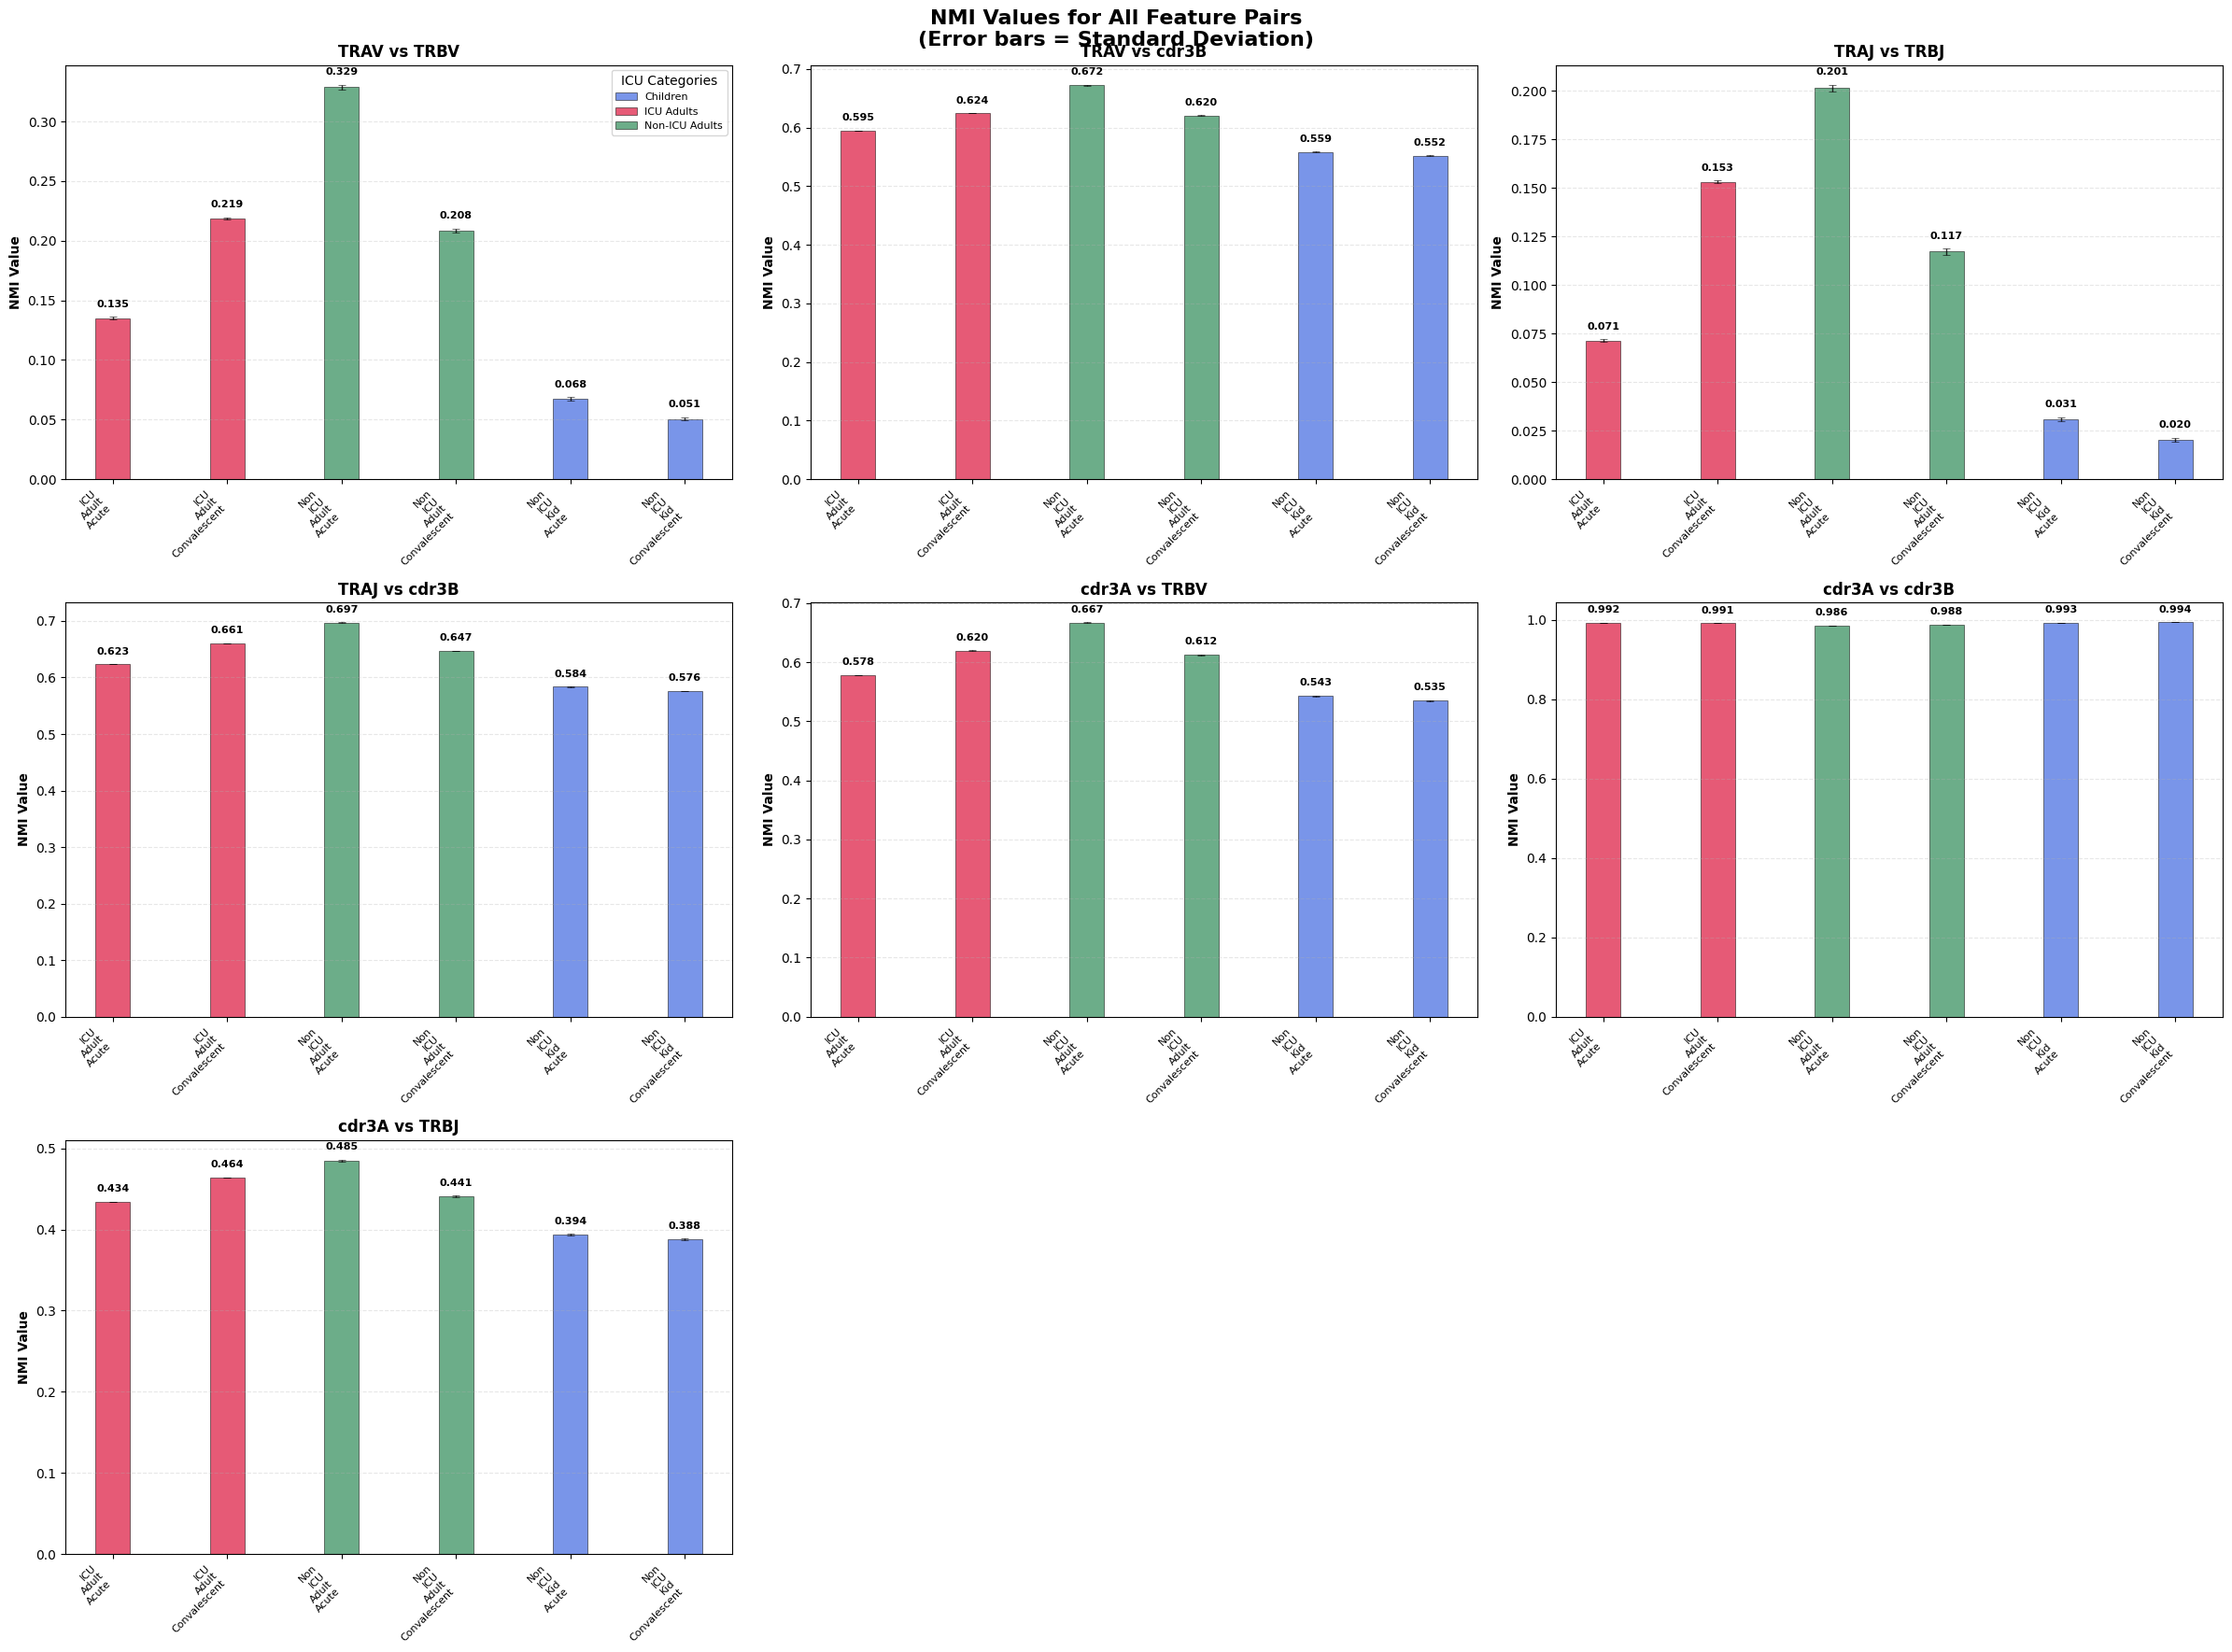

Combined p-value heatmaps saved to: /mnt/d/TCRMI/figures/covid_children/ICU_status/MI_pvalue_heatmaps_combined.pdf


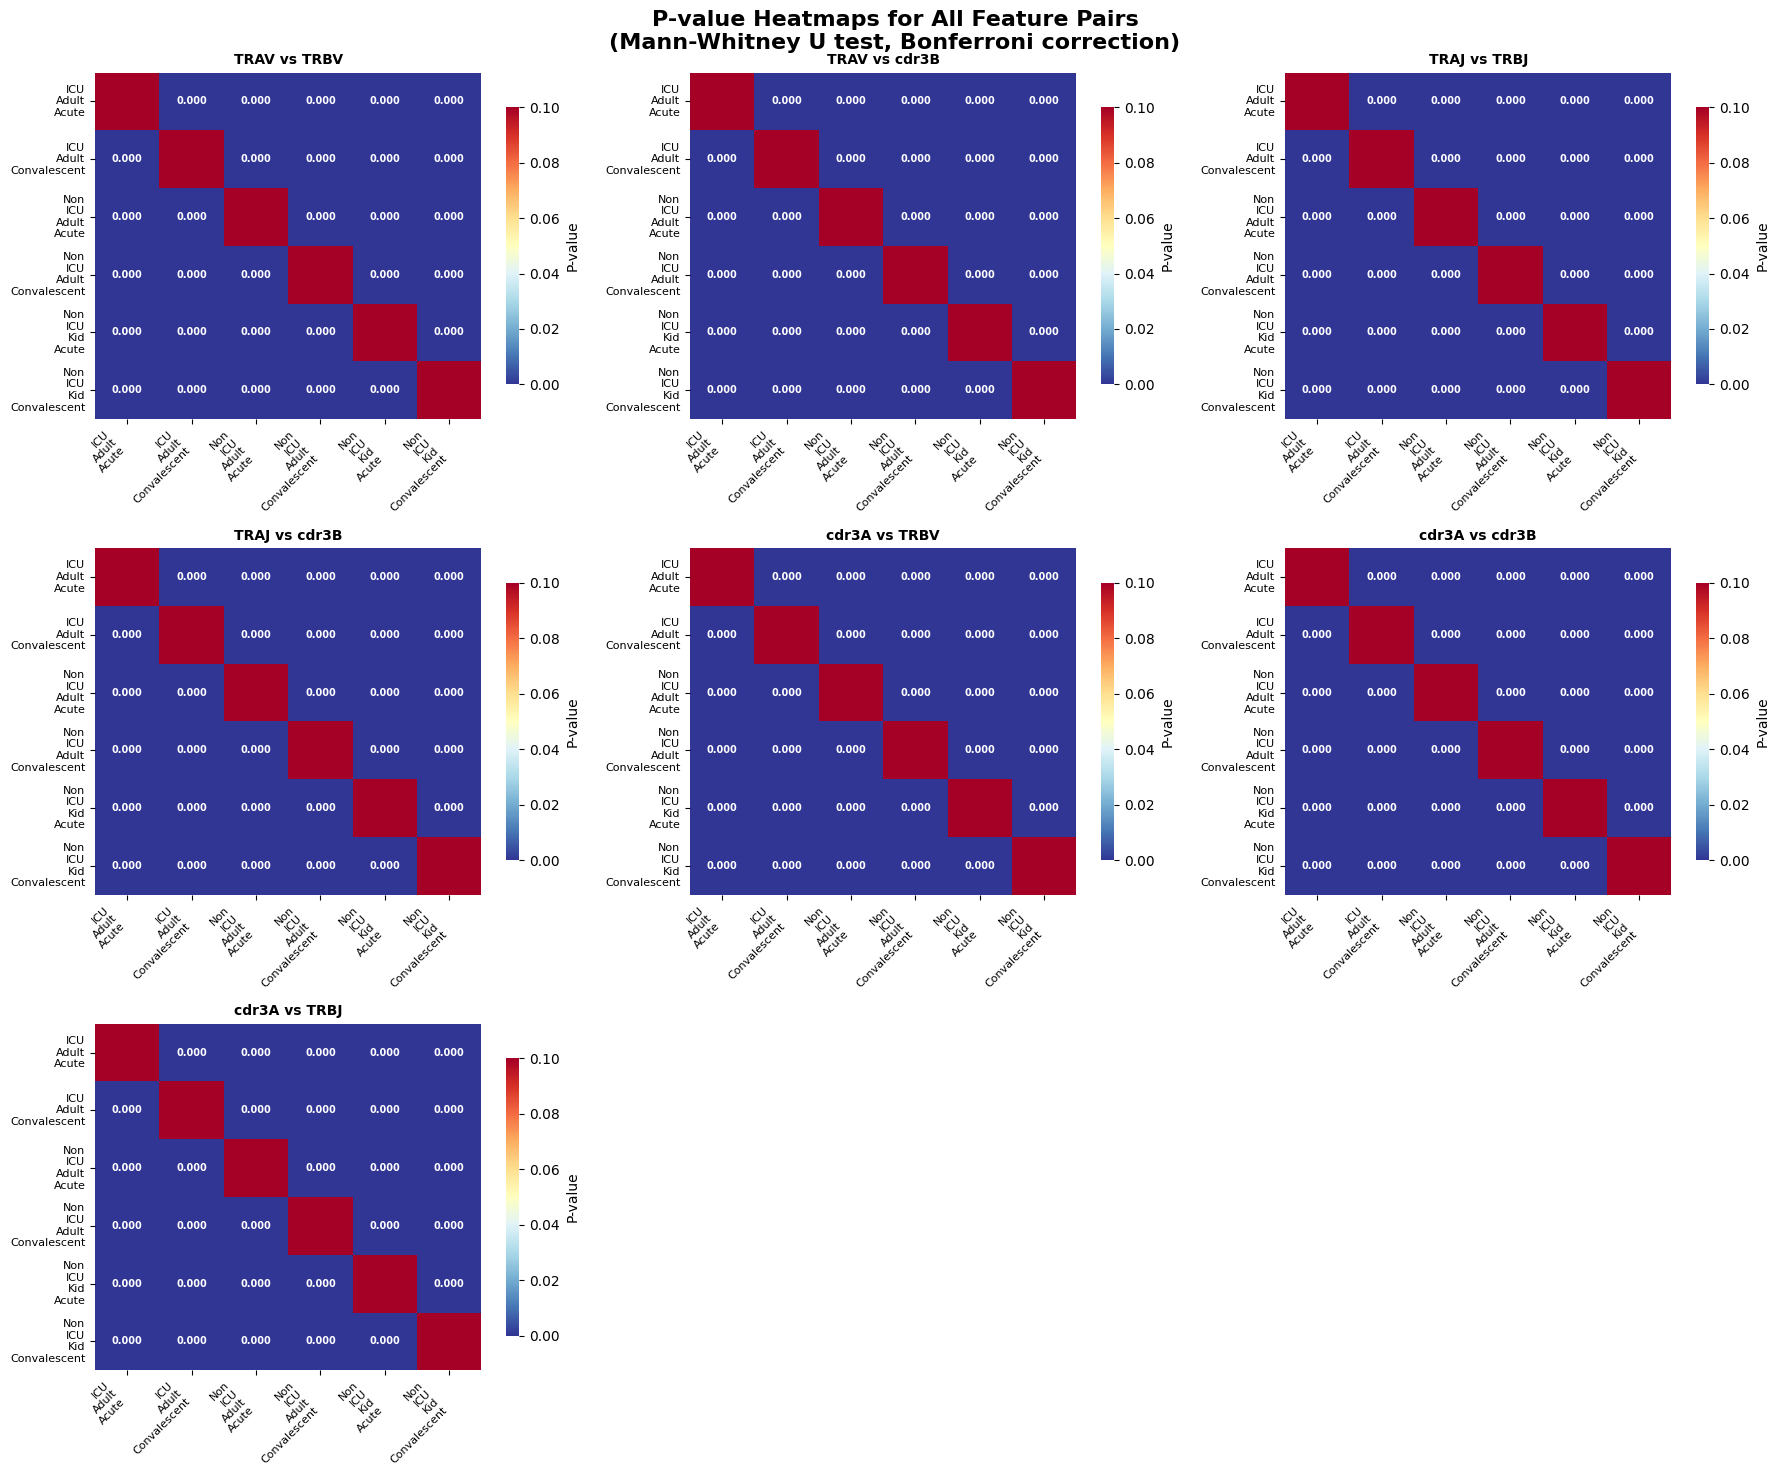

In [35]:
create_mi_plot('/mnt/d/TCRMI/results/covid_children/ICU_status/mi.pickle',
               '/mnt/d/TCRMI/results/covid_children/ICU_status.pickle',
               save_dir="/mnt/d/TCRMI/figures/covid_children/ICU_status", #"/mnt/d/TCRMI/figures/covid_children/ICU_status", 
               select_features=[('TRAV','TRBV'),('TRAV','cdr3B'),
                                ('cdr3A','cdr3B'), ('cdr3A','TRBV'),
                                ('cdr3A', 'TRBJ'), ('TRAJ', 'cdr3B'), ('TRAJ','TRBJ')])

In [20]:
def get_ICU_category(patient_id):
    try:
        # Filter metadata for the specific patient
        patient_data = metadata[metadata['patient_status'] == patient_id]
        
        if patient_data.empty:
            raise ValueError(f"Patient ID '{patient_id}' not found in metadata")
        
        # Get the ICU value
        icu_value = patient_data['ICU'].iloc[0]  # Use iloc[0] instead of unique()[0]
        
        # Categorize based on ICU value
        if 'Non_ICU' in icu_value and 'Adult' in icu_value:
            return 'Non-ICU Adults'
        elif 'Non' not in icu_value and 'ICU_Adult' in icu_value:
            return 'ICU Adults'
        elif 'Kid' in icu_value:
            return 'Children'
        else:
            return icu_value
            
    except KeyError as e:
        raise KeyError(f"Required column missing from metadata: {e}")
    except Exception as e:
        raise Exception(f"Error processing patient {patient_id}: {e}")

def get_patient_ID(patientid):
    """Extract response category from sample ID"""
    return metadata[metadata['patient_status'] == patientid].Patient.unique()[0]

def get_age_status_category(patientid):
    """Extract response category from sample ID"""
    return metadata[metadata['patient_status'] == patientid].Age_status.unique()[0]

def get_status_category(patientid):
    """Extract response category from sample ID"""
    temp = metadata[metadata['patient_status'] == patientid].Age_status.unique()[0]
    if 'Acute' in temp:
        return 'Acute'
    else:
        return 'Convalescent'

def perform_statistical_tests(df_plot, unique_samples, test_direction='two-sided', adjust_pvalues=True, adjust_method="FDR"):
    """
    Perform pairwise statistical comparisons between all samples
    
    Parameters:
    test_direction: 'greater', 'less', or 'two-sided'
        - 'greater': Test if Sample1 > Sample2 (Sample1 has higher MI values)
        - 'less': Test if Sample1 < Sample2 (Sample1 has lower MI values)
        - 'two-sided': Test if Sample1 ≠ Sample2 (any difference)
    """
    from statsmodels.stats.multitest import multipletests
    from itertools import combinations
    import scipy.stats as stats
    
    all_results = []
    
    # Get MI values for each sample
    sample_data = {}
    for sample in unique_samples:
        sample_data[sample] = df_plot[df_plot['Sample_ID'] == sample]['MI_Value'].values
    
    # Perform pairwise comparisons
    total_comparisons = 0
    for sample1, sample2 in combinations(unique_samples, 2):
        total_comparisons += 1
        data1 = sample_data[sample1]
        data2 = sample_data[sample2]
        
        # Calculate all three types of tests
        _, p_greater = stats.mannwhitneyu(data1, data2, alternative='greater')
        _, p_less = stats.mannwhitneyu(data1, data2, alternative='less')
        _, p_two_sided = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        # Select p-value based on test direction
        if test_direction == 'two-sided':
            p_raw = p_two_sided
        elif test_direction == 'greater':
            p_raw = p_greater
        elif test_direction == 'less':
            p_raw = p_less
        else:
            p_raw = p_two_sided
        
        all_results.append({
            'Sample1': sample1,
            'Sample2': sample2,
            'Sample1_ICU': get_ICU_category(sample1),
            'Sample2_ICU': get_ICU_category(sample2),
            'Sample1_status': get_age_status_category(sample1),
            'Sample2_status': get_age_status_category(sample2),
            'Sample1_Mean': np.mean(data1),
            'Sample2_Mean': np.mean(data2),
            'Mean_Difference': np.mean(data1) - np.mean(data2),
            'P_Value_Raw': p_raw,
            'P_Value_less': p_less,
            'P_Value_greater': p_greater,
            'P_Value_Two_Sided': p_two_sided,
            'N1': len(data1), 
            'N2': len(data2),
            'Test_Direction': test_direction
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(all_results)
    
    if adjust_pvalues:
        # Apply multiple testing correction to the main p-value
        p_values = results_df['P_Value_Raw'].values 
        
        # Benjamini-Hochberg (FDR) - less conservative than Bonferroni
        rejected_fdr, p_adjusted_fdr, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Bonferroni - more conservative
        rejected_bonf, p_adjusted_bonf, _, _ = multipletests(p_values, method='bonferroni')
        
        results_df['P_Value_FDR'] = p_adjusted_fdr
        results_df['P_Value_Bonferroni'] = p_adjusted_bonf
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        results_df['Significant_FDR'] = rejected_fdr
        results_df['Significant_Bonferroni'] = rejected_bonf
        
        # Filter significant results (you can choose which method to use)
        if adjust_method == "FDR":
            found_significant = results_df[results_df['Significant_FDR']].copy()
        else:
            found_significant = results_df[results_df['Significant_Bonferroni']].copy()
        
    else:
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        found_significant = results_df[results_df['Significant_Raw']].copy()
        
    return results_df, found_significant

def create_individual_barplot_errorbar(df_stats, unique_samples, feature1, feature2, color_dict, 
                                     category_func, legend_title, save_dir=None):
    """
    Create individual bar plot with error bars and save it
    """
    # Create figure without showing it
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Get unique categories and their colors for the current coloring scheme
    all_categories = [category_func(sample) for sample in unique_samples]
    unique_categories = list(set(all_categories))
    
    # Ensure all categories have colors (add default colors if needed)
    for cat in unique_categories:
        if cat not in color_dict:
            color_dict[cat] = '#808080'  # Default gray for unknown categories
    
    # Create sample-specific colors
    sample_colors = [color_dict.get(category_func(sample), '#808080') for sample in unique_samples]
    
    # CREATE BAR PLOT WITH ERROR BARS
    x_positions = np.arange(len(unique_samples))
    bar_width = 0.5
    
    # Create bars
    bars = ax.bar(x_positions, df_stats['Mean'], bar_width,
                 color=sample_colors, alpha=0.7,
                 edgecolor='black', linewidth=0.5)
    
    # Add error bars (mean ± standard error)
    ax.errorbar(x_positions, df_stats['Mean'], yerr=df_stats['SE'], 
               color='black', capsize=8, capthick=0.5, 
               linewidth=2, alpha=0.8, fmt='none')
    
    # Add group separation lines
    icu_boundaries = []
    current_icu = None
    for i, sample in enumerate(unique_samples):
        sample_icu = get_ICU_category(sample)
        if current_icu is not None and sample_icu != current_icu:
            icu_boundaries.append(i - 0.5)
        current_icu = sample_icu
    
    # Draw separation lines
    for boundary in icu_boundaries:
        ax.axvline(x=boundary, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    
    # Customize the plot
    ax.set_title(f'{feature1} vs {feature2}',
                fontsize=14, fontweight='bold')
    #ax.set_xlabel('Sample ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Mutual Information Value', fontsize=12, fontweight='bold')
    
    # Set x-axis labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(unique_samples, rotation=45, ha='right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    
    # Create custom legend for categories
    legend_elements = []
    for category in sorted(unique_categories):
        if category in color_dict:
            legend_elements.append(
                plt.Rectangle((0,0),1,1, facecolor=color_dict[category], alpha=0.7, label=category)
            )
    
    # Add legend for error bars
    legend_elements.append(
        plt.Line2D([0], [0], color='black', linestyle='-', linewidth=2,
                  label='Mean ± SE')
    )
    
    ax.legend(handles=legend_elements, title=f'{legend_title} & Statistics', 
             loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=10)
    
    plt.tight_layout()
    
    # Save individual bar plot
    if save_dir:
        save_path = os.path.join(save_dir, f'MI_barplot_errorbar_{feature1}_vs_{feature2}.pdf')
        plt.savefig(save_path, transparent=True, bbox_inches='tight')
        print(f"Bar plot with error bars saved to: {save_path}")
    
    # Close the figure to prevent it from showing
    plt.close(fig)
    
    return fig

def create_mi_plot(mi_path, samples_path, color_by='ICU_Category', save_dir=None, 
                   p_value_type='P_Value_Bonferroni', select_features=None):
    """
    Create BAR PLOTS with error bars showing mean MI values and their standard errors.
    Save individual plots separately and create combined plots that are shown in notebook.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    # Define color palettes for different categorizations
    icu_colors = {
        'Non-ICU Adults': '#2E8B57',    # Sea Green
        'ICU Adults': '#DC143C',        # Crimson
        'Children': '#4169E1'           # Royal Blue
    }
    
    # Age status colors (you can customize these based on your Age_status categories)
    age_status_colors = {
        'Adult_Acute': '#FF6B35',      # Orange Red
        'Adult_Convalescent': '#4ECDC4',  # Turquoise
        'Kid_Acute': '#DDA0DD',
        'Kid_Convalescent': '#1B64A4',    # Sky Blue
    }
    
    # Choose color scheme based on parameter
    if color_by == 'ICU_Category':
        color_dict = icu_colors
        category_func = get_ICU_category
        legend_title = 'ICU Categories'
        response_order = ['ICU Adults', 'Non-ICU Adults', 'Children']  # ICU排序
    elif color_by == 'Age_status':
        color_dict = age_status_colors
        category_func = get_age_status_category
        legend_title = 'Age Status'
        response_order = ['Adult_Acute', 'Adult_Convalescent', 'Kid_Acute', 'Kid_Convalescent']
    else:
        raise ValueError("color_by must be either 'ICU_Category' or 'Age_status'")
    
    # Define Age_status order
    age_status_order = ['Adult_Acute', 'Adult_Convalescent', 'Kid_Acute', 'Kid_Convalescent']
    
    # Storage for all feature results
    all_feature_stats = {}
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        sample_ids = list(data_dict.keys())
    
        # Prepare plot data
        plot_data = []
        for sample_idx, sample_id in enumerate(sample_ids):
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    if sample_idx < len(mi_values_array):
                        plot_data.append({
                            'Sample_ID': sample_id,
                            'Patient_ID': get_patient_ID(sample_id),
                            'Age_status': get_age_status_category(sample_id),
                            'status': get_status_category(sample_id),
                            'ICU_Category': get_ICU_category(sample_id),
                            'MI_Value': mi_values_array[sample_idx],
                            'Resample_Index': resample_idx
                        })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        # Hierarchical sorting logic
        def sort_key_hierarchical(sample_id):
            icu_category = get_ICU_category(sample_id)
            age_status = get_age_status_category(sample_id)
            
            # ICU category priority
            icu_priority = response_order.index(icu_category) if icu_category in response_order else 999
            
            # Age_status priority
            age_status_priority = age_status_order.index(age_status) if age_status in age_status_order else 999
            
            return (icu_priority, age_status_priority)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_hierarchical)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Calculate summary statistics for BAR PLOT
        summary_stats = []
        for sample in unique_samples:
            sample_data = df_plot_limited[df_plot_limited['Sample_ID'] == sample]['MI_Value']
            summary_stats.append({
                'Sample_ID': sample,
                'Mean': sample_data.mean(),
                'Std': sample_data.std(),
                'SE': sample_data.std() / np.sqrt(len(sample_data)),
                'Category': category_func(sample),
                'N': len(sample_data)
            })
        
        df_stats = pd.DataFrame(summary_stats)
        
        if select_features is None or (feature1, feature2) in select_features:
            # Store results for combined plot
            all_feature_stats[(feature1, feature2)] = {
                'df_stats': df_stats,
                'unique_samples': unique_samples
            }
            
            # Create and save individual bar plot (without showing)
            create_individual_barplot_errorbar(df_stats, unique_samples, feature1, feature2, 
                                            color_dict, category_func, legend_title, save_dir)
    
    # Create combined bar plots figure (this will be shown)
    if all_feature_stats:
        n_features = len(all_feature_stats)
        n_cols = min(3, n_features)  # Max 3 columns
        n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
        
        # Handle single subplot case
        if n_features == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()
        
        for idx, ((feature1, feature2), data_dict_item) in enumerate(all_feature_stats.items()):
            ax = axes[idx] if n_features > 1 else axes[0]
            
            df_stats = data_dict_item['df_stats']
            unique_samples = data_dict_item['unique_samples']
            
            # Get unique categories and their colors for the current coloring scheme
            all_categories = [category_func(sample) for sample in unique_samples]
            unique_categories = list(set(all_categories))
            
            # Ensure all categories have colors (add default colors if needed)
            for cat in unique_categories:
                if cat not in color_dict:
                    color_dict[cat] = '#808080'  # Default gray for unknown categories
            
            # Create sample-specific colors
            sample_colors = [color_dict.get(category_func(sample), '#808080') for sample in unique_samples]
            
            # CREATE BAR PLOT WITH ERROR BARS
            x_positions = np.arange(len(unique_samples))
            bar_width = 0.5
            
            # Create bars
            bars = ax.bar(x_positions, df_stats['Mean'], bar_width,
                         color=sample_colors, alpha=0.7,
                         edgecolor='black', linewidth=0.5)
            
            # Add error bars (mean ± standard error)
            ax.errorbar(x_positions, df_stats['Mean'], yerr=df_stats['SE'], 
                       color='black', capsize=5, capthick=0.5, 
                       linewidth=1.5, alpha=0.8, fmt='none')
            
            # Add group separation lines
            icu_boundaries = []
            current_icu = None
            for i, sample in enumerate(unique_samples):
                sample_icu = get_ICU_category(sample)
                if current_icu is not None and sample_icu != current_icu:
                    icu_boundaries.append(i - 0.5)
                current_icu = sample_icu
            
            # Draw separation lines
            for boundary in icu_boundaries:
                ax.axvline(x=boundary, color='black', linestyle='--', alpha=0.5, linewidth=1)
            
            # Customize the plot
            ax.set_title(f'{feature1} vs {feature2}', fontsize=12, fontweight='bold')
            #ax.set_xlabel('Sample ID', fontsize=10, fontweight='bold')
            ax.set_ylabel('Mean NMI Value', fontsize=10, fontweight='bold')
            
            # Set x-axis labels
            ax.set_xticks(x_positions)
            ax.set_xticklabels([s for s in unique_samples], 
                              rotation=45, ha='right', fontsize=8)
            ax.grid(True, alpha=0.3, axis='y', linestyle=':')
            
            # Create custom legend for categories (only for first subplot)
            if idx == 0:
                legend_elements = []
                for category in sorted(unique_categories):
                    if category in color_dict:
                        legend_elements.append(
                            plt.Rectangle((0,0),1,1, facecolor=color_dict[category], alpha=0.7, label=category)
                        )
                
                # Add legend for error bars
                legend_elements.append(
                    plt.Line2D([0], [0], color='black', linestyle='-', linewidth=1.5,
                              label='Mean ± SE')
                )
                
                ax.legend(handles=legend_elements, title=f'{legend_title} & Statistics', 
                         loc='upper right', fontsize=8)
        
        # Hide unused subplots
        for idx in range(n_features, len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle(f'Mean MI Values with Error Bars for All Feature Pairs\n'
                     f'(Colored by {color_by.replace("_", " ")}, Ordered by ICU Category then Age Status)', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        # Save combined bar plots
        if save_dir:
            save_path = os.path.join(save_dir, f'MI_barplots_errorbar_combined_{color_by}.pdf')
            plt.savefig(save_path, transparent=True, bbox_inches='tight')
            print(f"Combined bar plots with error bars saved to: {save_path}")
        
        # Show combined bar plots
        plt.show()

Processing TRAV vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/MI_barplot_errorbar_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/MI_barplot_errorbar_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/MI_barplot_errorbar_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/MI_barplot_errorbar_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/MI_barplot_errorbar_cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/MI_barplot_errorbar_cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/MI_barplot_errorbar_cdr3A

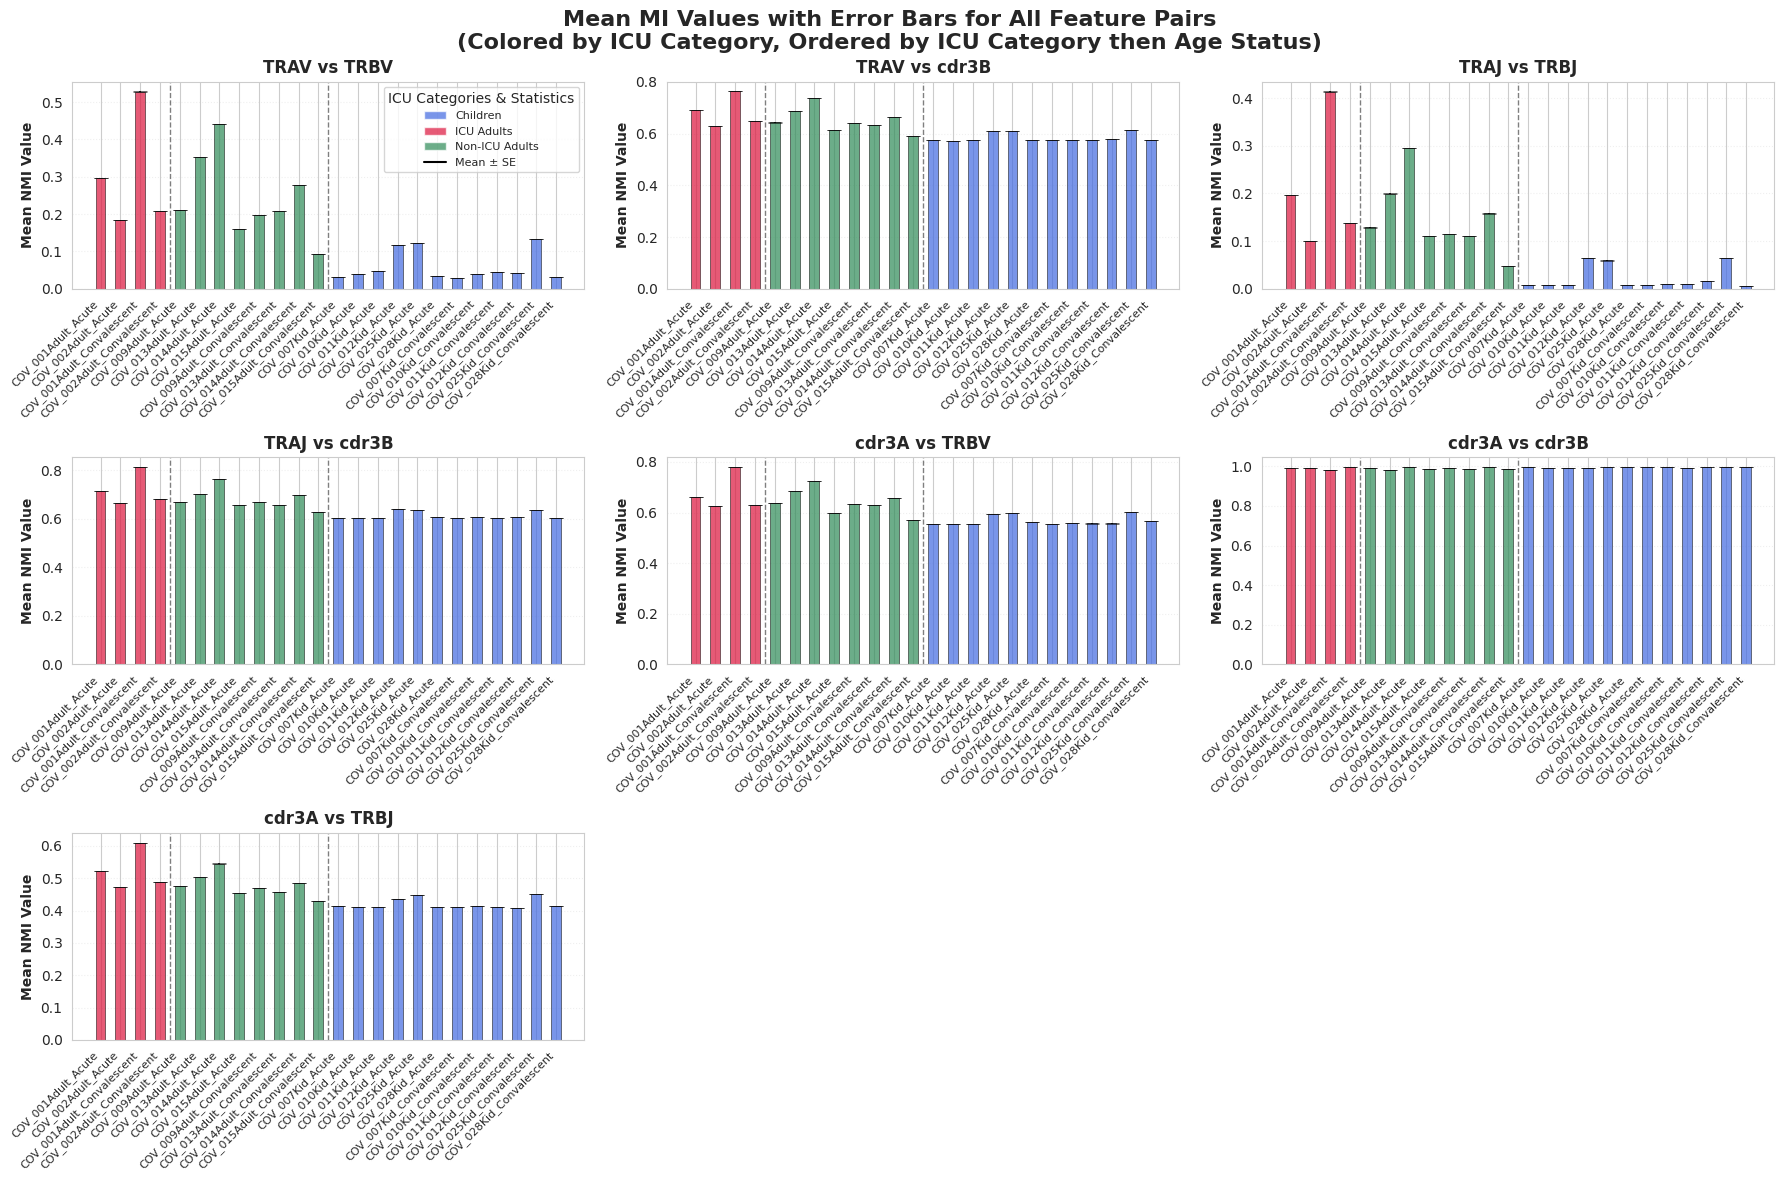

In [21]:
create_mi_plot('/mnt/d/TCRMI/results/covid_children/samples/mi.pickle',
               '/mnt/d/TCRMI/results/covid_children/samples.pickle',
               save_dir="/mnt/d/TCRMI/figures/covid_children/samples", 
               select_features=[('TRAV','TRBV'),('TRAV','cdr3B'),
                                ('cdr3A','cdr3B'), ('cdr3A','TRBV'),
                                ('cdr3A', 'TRBJ'), ('TRAJ', 'cdr3B'), ('TRAJ','TRBJ')])

Processing TRAV vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4naive/MI_barplot_errorbar_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4naive/MI_barplot_errorbar_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4naive/MI_barplot_errorbar_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4naive/MI_barplot_errorbar_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4naive/MI_barplot_errorbar_cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4naive/MI_barplot_errorbar_cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/fi

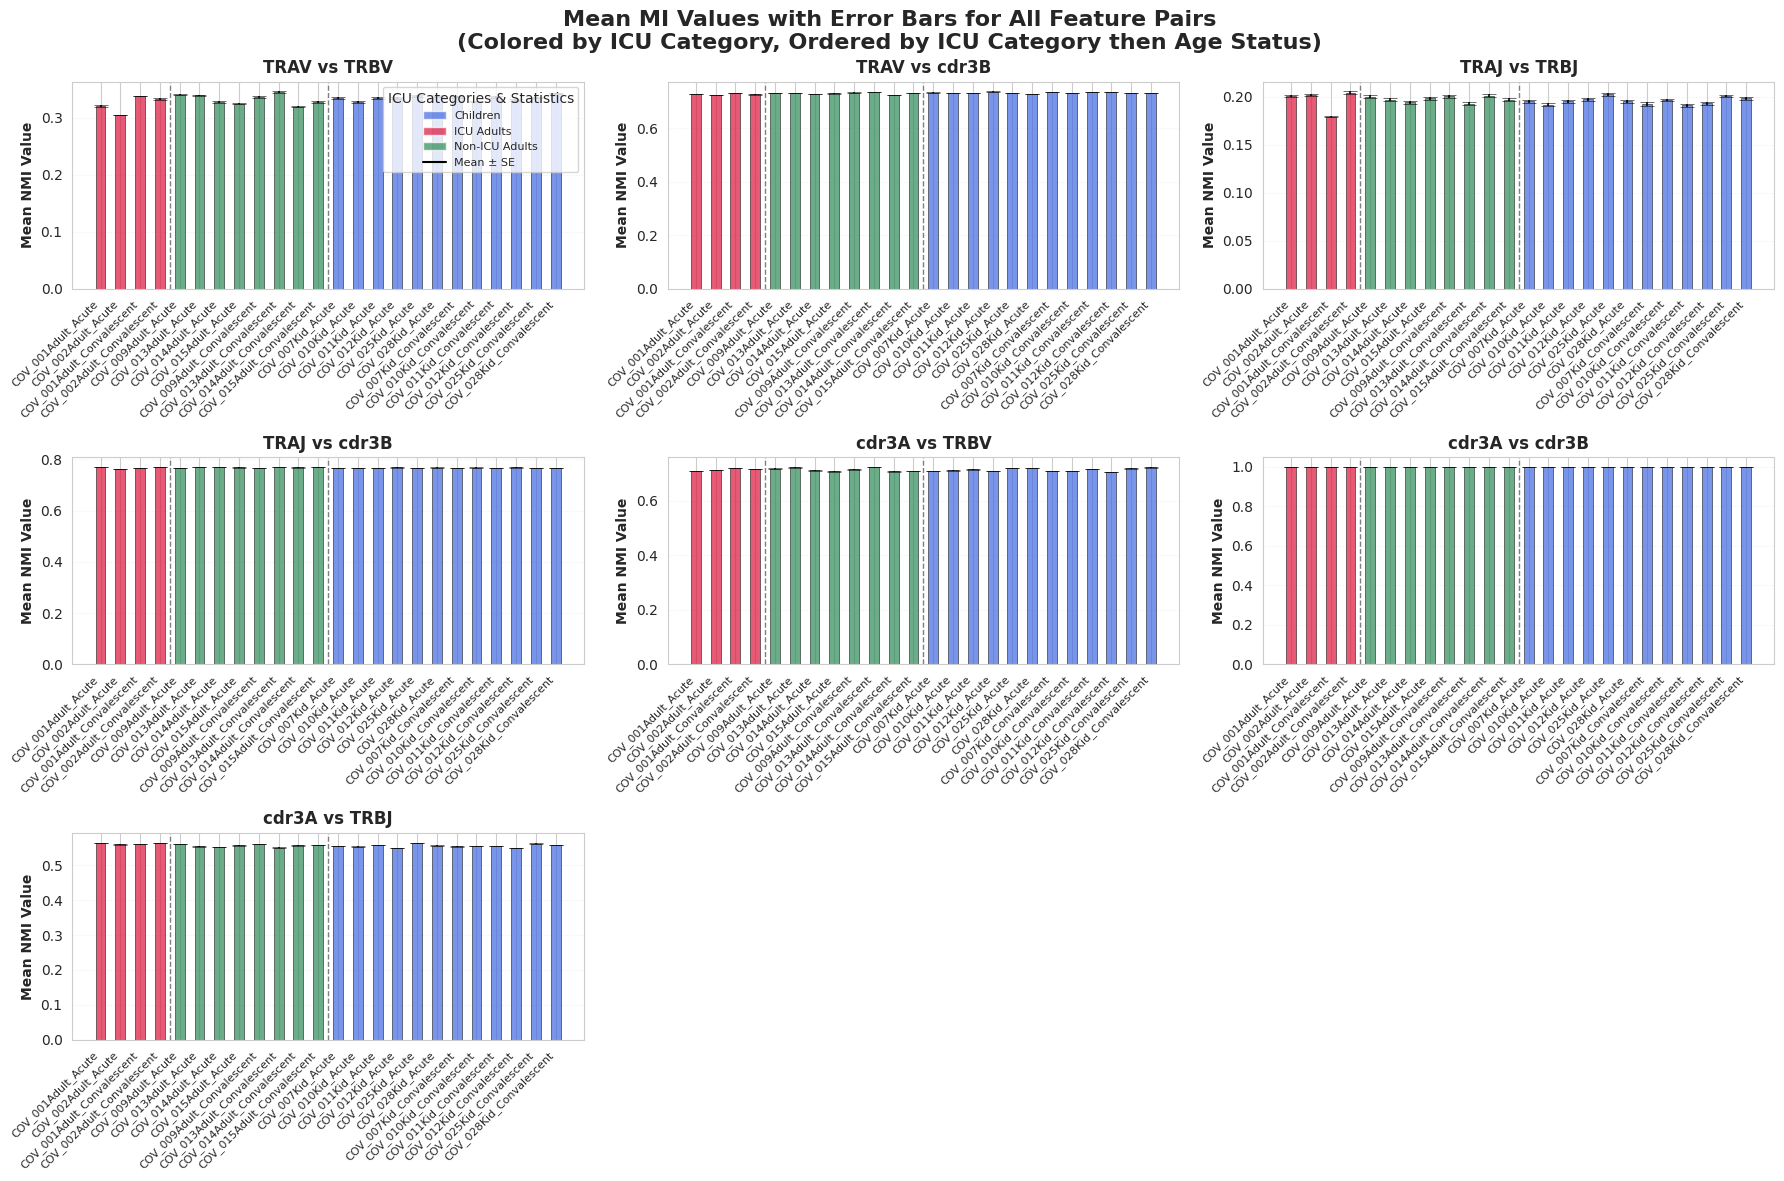

Processing TRAV vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4TEM/MI_barplot_errorbar_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4TEM/MI_barplot_errorbar_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4TEM/MI_barplot_errorbar_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4TEM/MI_barplot_errorbar_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4TEM/MI_barplot_errorbar_cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD4TEM/MI_barplot_errorbar_cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_

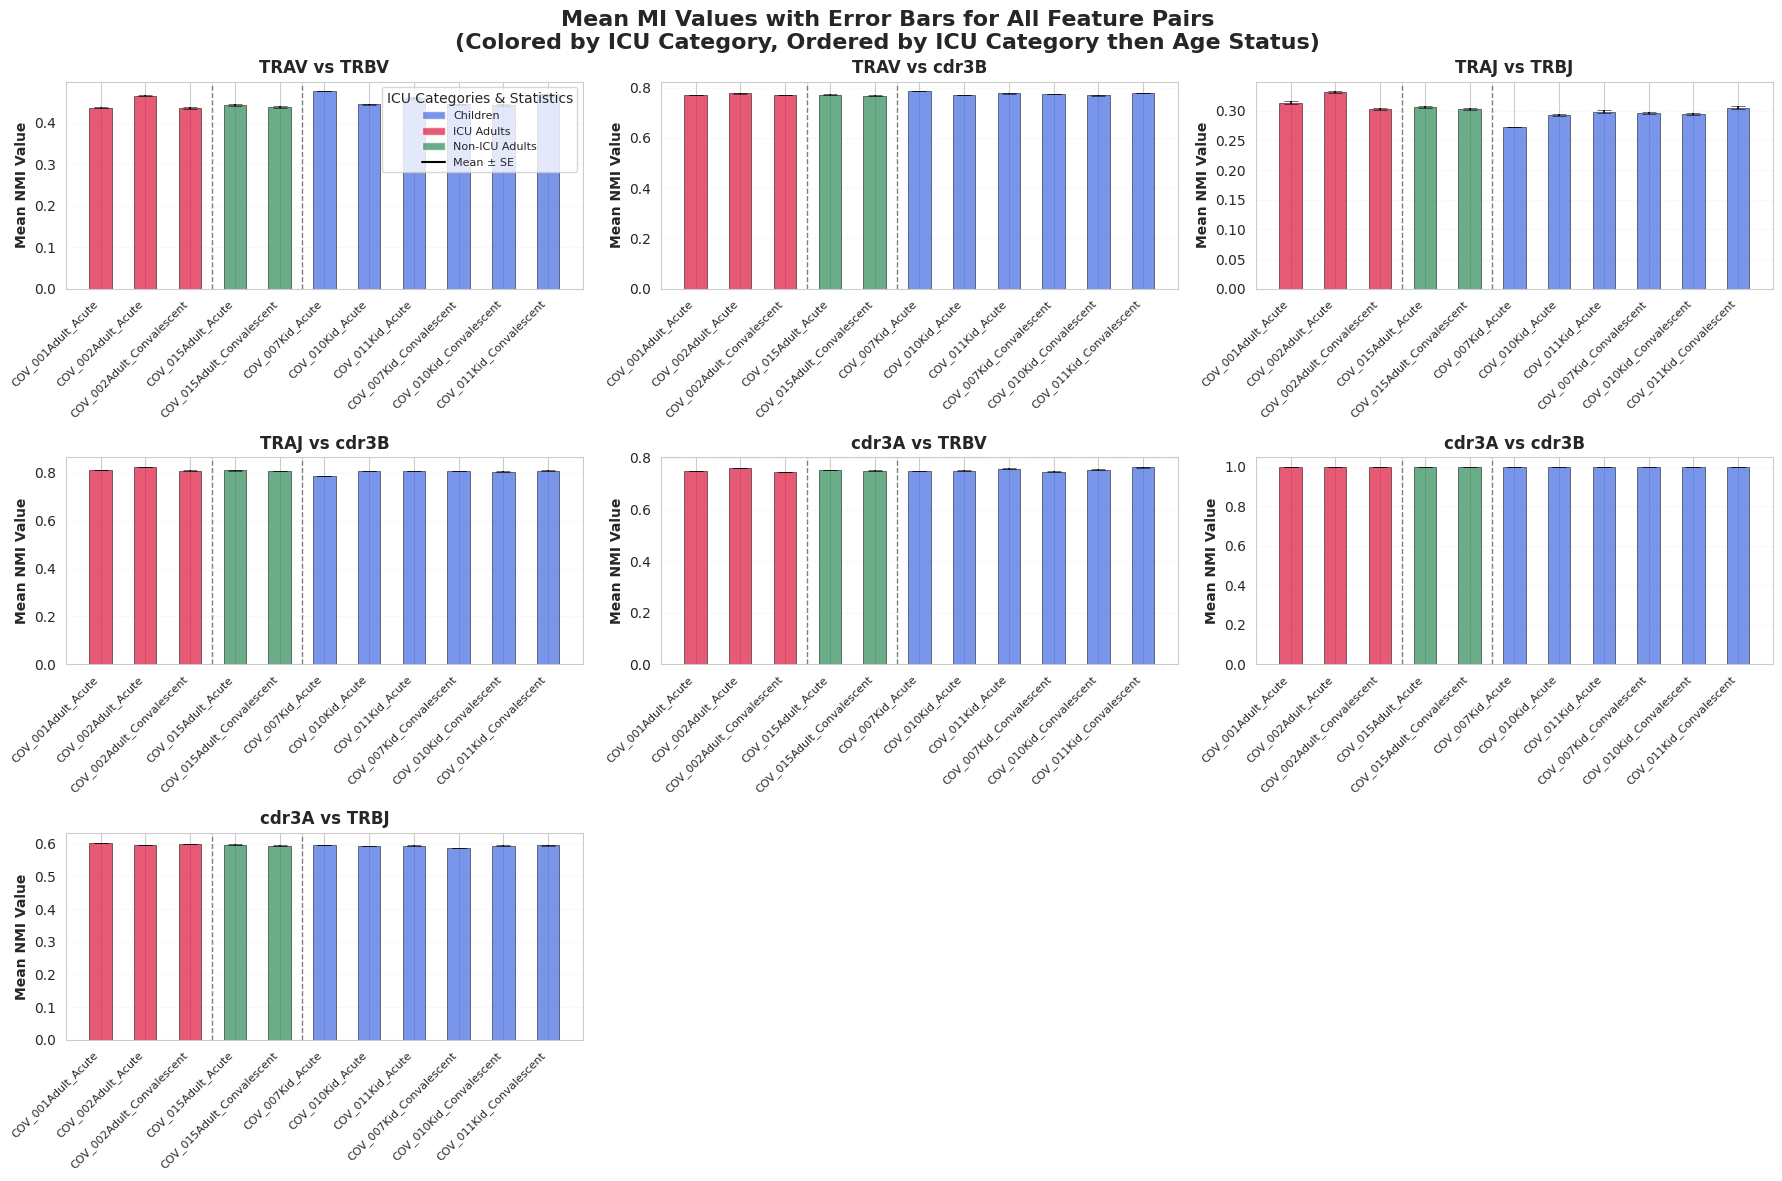

Processing TRAV vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8TEM/MI_barplot_errorbar_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8TEM/MI_barplot_errorbar_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8TEM/MI_barplot_errorbar_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8TEM/MI_barplot_errorbar_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8TEM/MI_barplot_errorbar_cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8TEM/MI_barplot_errorbar_cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_

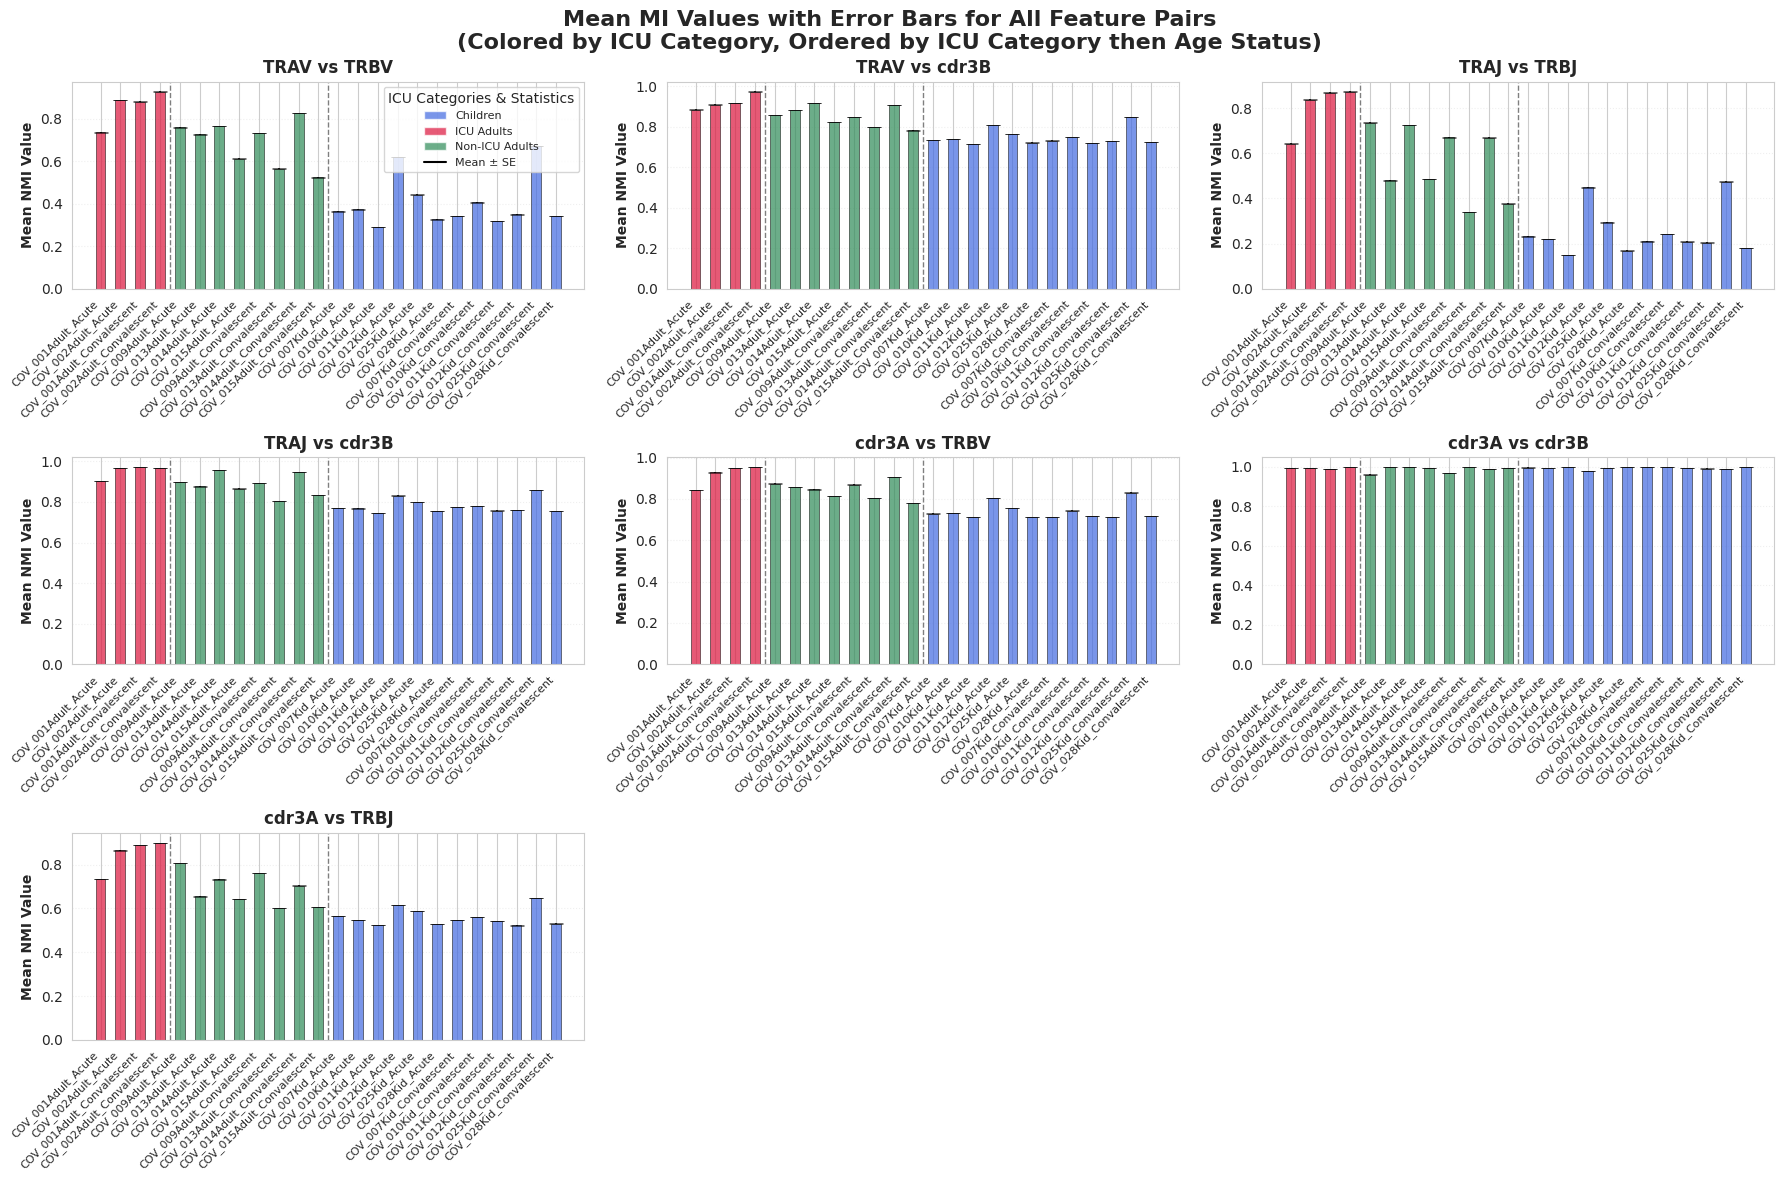

Processing TRAV vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8naive/MI_barplot_errorbar_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8naive/MI_barplot_errorbar_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8naive/MI_barplot_errorbar_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8naive/MI_barplot_errorbar_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8naive/MI_barplot_errorbar_cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Bar plot with error bars saved to: /mnt/d/TCRMI/figures/covid_children/samples/CD8naive/MI_barplot_errorbar_cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Bar plot with error bars saved to: /mnt/d/TCRMI/fi

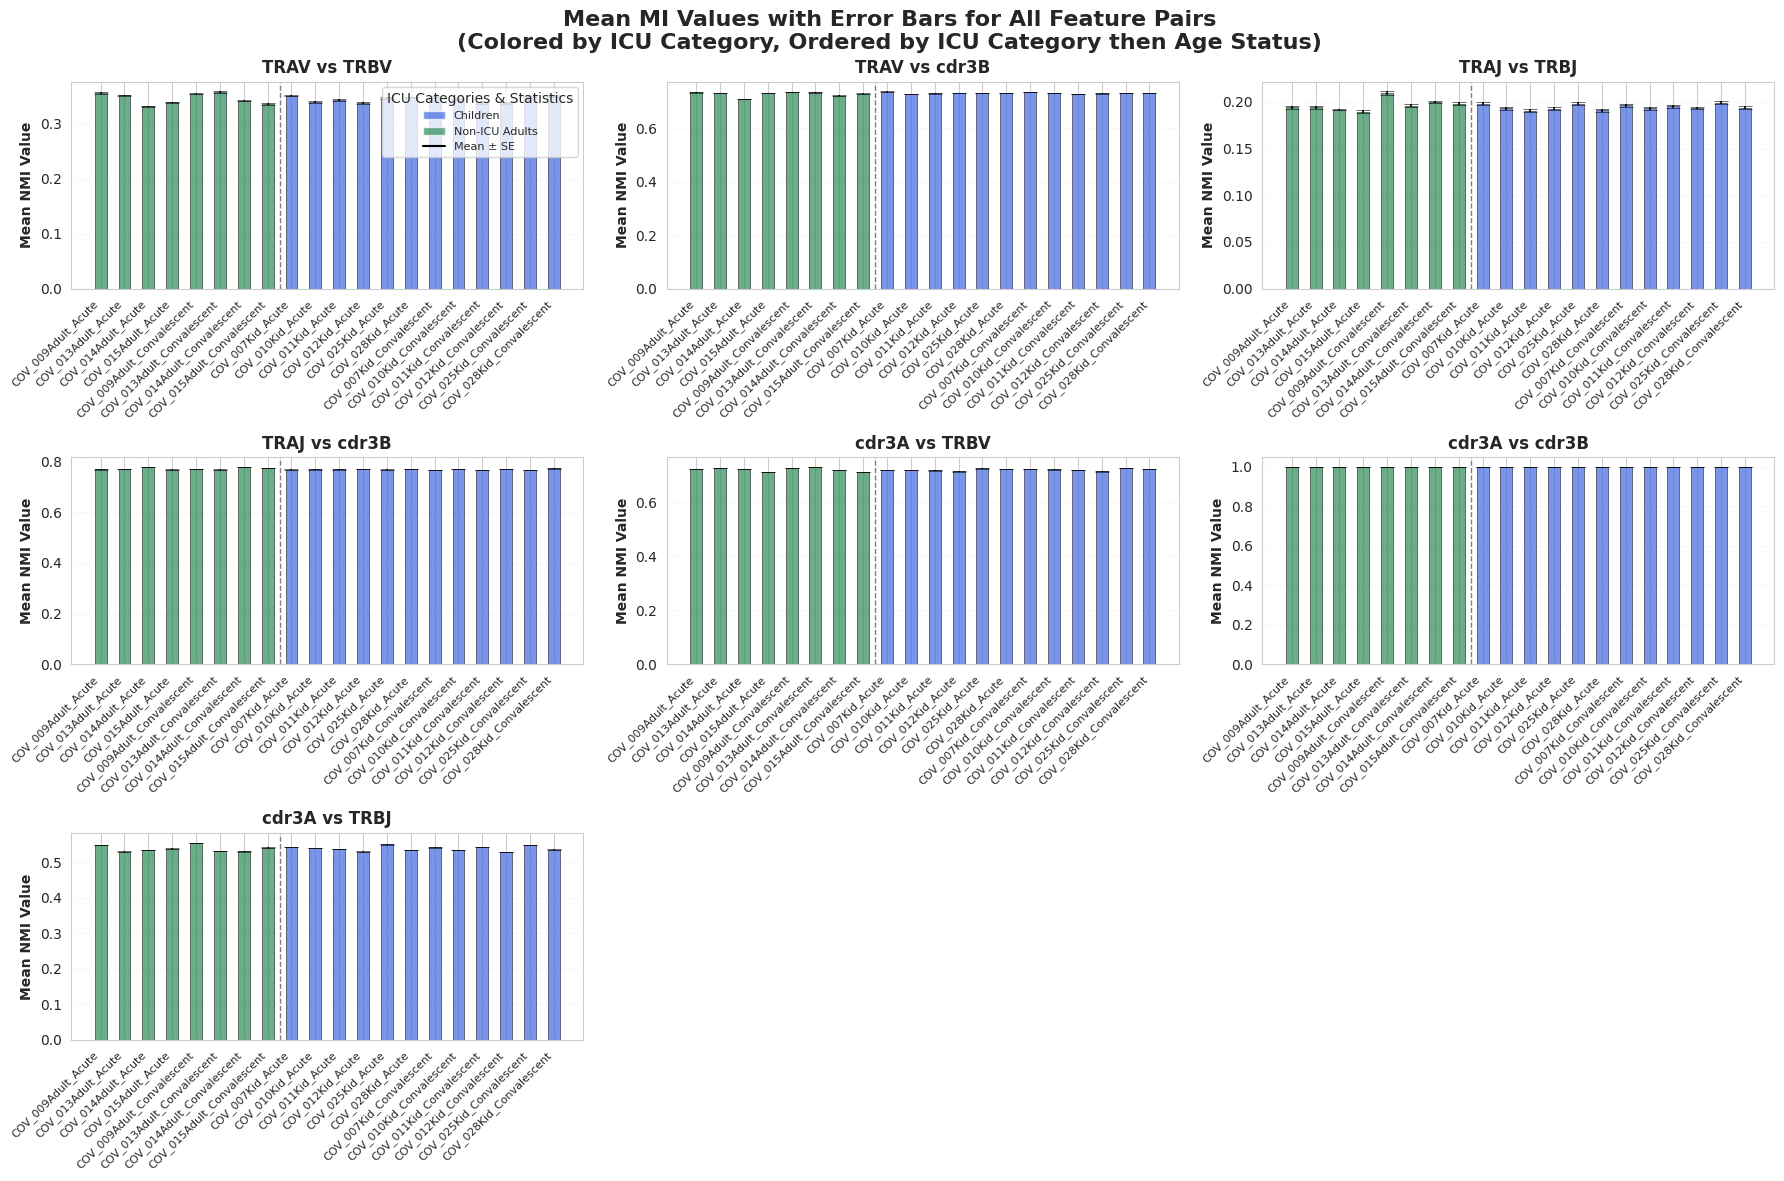

In [22]:
create_mi_plot('/mnt/d/TCRMI/results/covid_children/CD4naivesamples/mi.pickle',
               '/mnt/d/TCRMI/results/covid_children/CD4naivesamples.pickle',
               save_dir="/mnt/d/TCRMI/figures/covid_children/samples/CD4naive", 
               select_features=[('TRAV','TRBV'),('TRAV','cdr3B'),
                                ('cdr3A','cdr3B'), ('cdr3A','TRBV'),
                                ('cdr3A', 'TRBJ'), ('TRAJ', 'cdr3B'), ('TRAJ','TRBJ')])

create_mi_plot('/mnt/d/TCRMI/results/covid_children/CD4TEMsamples/mi.pickle',
               '/mnt/d/TCRMI/results/covid_children/CD4TEMsamples.pickle',
               save_dir="/mnt/d/TCRMI/figures/covid_children/samples/CD4TEM", 
               select_features=[('TRAV','TRBV'),('TRAV','cdr3B'),
                                ('cdr3A','cdr3B'), ('cdr3A','TRBV'),
                                ('cdr3A', 'TRBJ'), ('TRAJ', 'cdr3B'), ('TRAJ','TRBJ')])

create_mi_plot('/mnt/d/TCRMI/results/covid_children/CD8TEMsamples/mi.pickle',
               '/mnt/d/TCRMI/results/covid_children/CD8TEMsamples.pickle',
               save_dir="/mnt/d/TCRMI/figures/covid_children/samples/CD8TEM", 
               select_features=[('TRAV','TRBV'),('TRAV','cdr3B'),
                                ('cdr3A','cdr3B'), ('cdr3A','TRBV'),
                                ('cdr3A', 'TRBJ'), ('TRAJ', 'cdr3B'), ('TRAJ','TRBJ')])

create_mi_plot('/mnt/d/TCRMI/results/covid_children/CD8naivesamples/mi.pickle',
               '/mnt/d/TCRMI/results/covid_children/CD8naivesamples.pickle',
               save_dir="/mnt/d/TCRMI/figures/covid_children/samples/CD8naive", 
               select_features=[('TRAV','TRBV'),('TRAV','cdr3B'),
                                ('cdr3A','cdr3B'), ('cdr3A','TRBV'),
                                ('cdr3A', 'TRBJ'), ('TRAJ', 'cdr3B'), ('TRAJ','TRBJ')])

## paired line plot

In [9]:
def get_ICU_category(patient_id):
    try:
        # Filter metadata for the specific patient
        patient_data = metadata[metadata['patient_status'] == patient_id]
        
        if patient_data.empty:
            raise ValueError(f"Patient ID '{patient_id}' not found in metadata")
        
        # Get the ICU value
        icu_value = patient_data['ICU'].iloc[0]
        
        # Categorize based on ICU value
        if 'Non_ICU' in icu_value and 'Adult' in icu_value:
            return 'Non-ICU Adults'
        elif 'Non' not in icu_value and 'ICU_Adult' in icu_value:
            return 'ICU Adults'
        elif 'Kid' in icu_value:
            return 'Children'
        else:
            return icu_value
            
    except KeyError as e:
        raise KeyError(f"Required column missing from metadata: {e}")
    except Exception as e:
        raise Exception(f"Error processing patient {patient_id}: {e}")

def get_patient_ID(patientid):
    """Extract patient ID from sample ID"""
    return metadata[metadata['patient_status'] == patientid].Patient.unique()[0]

def get_age_status_category(patientid):
    """Extract age status category from sample ID"""
    return metadata[metadata['patient_status'] == patientid].Age_status.unique()[0]

def get_status_category(patientid):
    """Extract acute/convalescent status from sample ID"""
    temp = metadata[metadata['patient_status'] == patientid].Age_status.unique()[0]
    if 'Acute' in temp:
        return 'Acute'
    else:
        return 'Convalescent'

def create_individual_grouped_paired_plot(complete_patients, feature1, feature2, save_dir=None):
    """
    Create individual grouped paired plot and save it (without showing)
    """
    # Create figure without showing it
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Define colors for Acute vs Convalescent
    status_colors = {
        'Acute': '#1f77b4',      # Blue
        'Convalescent': '#F3627B'  # Orange
    }
    
    # Define x-axis positions for the three groups
    group_positions = {'Children': 0, 'Non-ICU Adults': 1, 'ICU Adults': 2}
    group_labels = ['Children', 'Non-ICU Adults', 'ICU Adults']
    
    # Plot individual patient trajectories and points
    for icu_cat in complete_patients['ICU_Category'].unique():
        if icu_cat not in group_positions:
            continue
            
        cat_data = complete_patients[complete_patients['ICU_Category'] == icu_cat]
        x_pos = group_positions[icu_cat]
        
        # Define slight offsets for Acute and Convalescent points within each group
        acute_offset = -0.1
        conv_offset = 0.1
        
        for _, row in cat_data.iterrows():
            # Plot individual patient points
            ax.scatter(x_pos + acute_offset, row['Acute_MI'], 
                      color=status_colors['Acute'], s=80, alpha=0.7, zorder=3)
            ax.scatter(x_pos + conv_offset, row['Conv_MI'], 
                      color=status_colors['Convalescent'], s=80, alpha=0.7, zorder=3)
            
            # Connect with line
            ax.plot([x_pos + acute_offset, x_pos + conv_offset], 
                   [row['Acute_MI'], row['Conv_MI']], 
                   color='gray', alpha=0.6, linewidth=1.5, zorder=2)
            
            # Add error bars for individual patients
            ax.errorbar(x_pos + acute_offset, row['Acute_MI'], 
                       yerr=row['Acute_SE'], color=status_colors['Acute'], 
                       capsize=4, alpha=0.7, zorder=1)
            ax.errorbar(x_pos + conv_offset, row['Conv_MI'], 
                       yerr=row['Conv_SE'], color=status_colors['Convalescent'], 
                       capsize=4, alpha=0.7, zorder=1)
    
    # Customize the plot
    ax.set_xlim(-0.5, 2.5)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(group_labels, fontsize=12, fontweight='bold')
    
    # Add "Acute Conv." labels under each group
    for i, group in enumerate(group_labels):
        ax.text(i, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05, 
               'Acute  Conv.', ha='center', va='top', fontsize=10, style='italic')
    
    ax.set_ylabel(f'{feature1} vs {feature2}\nMean Mutual Information Value', 
                 fontsize=12, fontweight='bold')
    ax.set_title(f'MI Value Changes: {feature1} vs {feature2}\n'
                f'Individual Patient Trajectories by ICU Category', 
                fontsize=14, fontweight='bold')
    
    # Create legend
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=status_colors['Acute'], 
               markersize=10, label='Acute'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=status_colors['Convalescent'], 
               markersize=10, label='Convalescent'),
        Line2D([0], [0], color='gray', linewidth=1.5, label='Individual Patient')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add sample size annotations
    for icu_cat in complete_patients['ICU_Category'].unique():
        if icu_cat not in group_positions:
            continue
        cat_data = complete_patients[complete_patients['ICU_Category'] == icu_cat]
        x_pos = group_positions[icu_cat]
        ax.text(x_pos, ax.get_ylim()[1], f'n={len(cat_data)}', 
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    
    # Save individual plot
    if save_dir:
        save_path = os.path.join(save_dir, f'{feature1}_vs_{feature2}.pdf')
        plt.savefig(save_path, transparent=True, bbox_inches='tight')
        print(f"Grouped paired plot saved to: {save_path}")
    
    # Close the figure to prevent it from showing
    plt.close(fig)
    
    return fig

def create_grouped_paired_plot(mi_path, samples_path, save_dir=None, select_features=None):
    """
    Create paired line plots with 3 ICU groups on x-axis, 
    showing Acute-Convalescent pairs within each group.
    Save individual plots separately and create combined plot that is shown in notebook.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    # Set seaborn style
    sns.set_style("whitegrid")
    
    # Define colors for Acute vs Convalescent
    status_colors = {
        'Acute': '#1f77b4',      # Blue
        'Convalescent': '#F3627B'  # Orange
    }
    
    # Storage for all feature results
    all_feature_data = {}
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        # Skip if not in selected features
        if select_features is not None and (feature1, feature2) not in select_features:
            continue
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        sample_ids = list(data_dict.keys())
    
        # Prepare plot data
        plot_data = []
        for sample_idx, sample_id in enumerate(sample_ids):
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    if sample_idx < len(mi_values_array):
                        plot_data.append({
                            'Sample_ID': sample_id,
                            'Patient_ID': get_patient_ID(sample_id),
                            'Age_status': get_age_status_category(sample_id),
                            'Status': get_status_category(sample_id),
                            'ICU_Category': get_ICU_category(sample_id),
                            'MI_Value': mi_values_array[sample_idx],
                            'Resample_Index': resample_idx
                        })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        # Calculate mean MI values for each patient-status combination
        patient_means = df_plot.groupby(['Patient_ID', 'Status', 'ICU_Category']).agg({
            'MI_Value': ['mean', 'std', 'count']
        }).reset_index()
        
        # Flatten column names
        patient_means.columns = ['Patient_ID', 'Status', 'ICU_Category', 'Mean_MI', 'Std_MI', 'Count']
        patient_means['SE_MI'] = patient_means['Std_MI'] / np.sqrt(patient_means['Count'])
        
        # Pivot to get Acute and Convalescent values for each patient
        pivot_data = patient_means.pivot_table(
            index=['Patient_ID', 'ICU_Category'], 
            columns='Status', 
            values=['Mean_MI', 'SE_MI'], 
            fill_value=np.nan
        ).reset_index()
        
        # Flatten column names
        pivot_data.columns = ['Patient_ID', 'ICU_Category', 'Acute_MI', 'Conv_MI', 'Acute_SE', 'Conv_SE']
        
        # Filter out patients that don't have both Acute and Convalescent data
        complete_patients = pivot_data.dropna(subset=['Acute_MI', 'Conv_MI'])
        
        if complete_patients.empty:
            print(f"No patients with both Acute and Convalescent data for {feature1} vs {feature2}")
            continue
        
        # Store data for combined plot
        all_feature_data[(feature1, feature2)] = complete_patients
        
        # Create and save individual plot (without showing)
        create_individual_grouped_paired_plot(complete_patients, feature1, feature2, save_dir)
    
    # Create combined plot figure (this will be shown)
    if all_feature_data:
        n_features = len(all_feature_data)
        n_cols = min(3, n_features)  # Max 3 columns
        n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))
        
        # Handle single subplot case
        if n_features == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()
        
        # Define x-axis positions for the three groups
        group_positions = {'Children': 0, 'Non-ICU Adults': 1, 'ICU Adults': 2}
        group_labels = ['Children', 'Non-ICU Adults', 'ICU Adults']
        
        for idx, ((feature1, feature2), complete_patients) in enumerate(all_feature_data.items()):
            ax = axes[idx] if n_features > 1 else axes[0]
            
            # Plot individual patient trajectories and points
            for icu_cat in complete_patients['ICU_Category'].unique():
                if icu_cat not in group_positions:
                    continue
                    
                cat_data = complete_patients[complete_patients['ICU_Category'] == icu_cat]
                x_pos = group_positions[icu_cat]
                
                # Define slight offsets for Acute and Convalescent points within each group
                acute_offset = -0.1
                conv_offset = 0.1
                
                for _, row in cat_data.iterrows():
                    # Plot individual patient points
                    ax.scatter(x_pos + acute_offset, row['Acute_MI'], 
                              color=status_colors['Acute'], s=60, alpha=0.7, zorder=3)
                    ax.scatter(x_pos + conv_offset, row['Conv_MI'], 
                              color=status_colors['Convalescent'], s=60, alpha=0.7, zorder=3)
                    
                    # Connect with line
                    ax.plot([x_pos + acute_offset, x_pos + conv_offset], 
                           [row['Acute_MI'], row['Conv_MI']], 
                           color='gray', alpha=0.6, linewidth=1, zorder=2)
                    
                    # Add error bars for individual patients (smaller for combined plot)
                    ax.errorbar(x_pos + acute_offset, row['Acute_MI'], 
                               yerr=row['Acute_SE'], color=status_colors['Acute'], 
                               capsize=3, alpha=0.7, zorder=1)
                    ax.errorbar(x_pos + conv_offset, row['Conv_MI'], 
                               yerr=row['Conv_SE'], color=status_colors['Convalescent'], 
                               capsize=3, alpha=0.7, zorder=1)
            
            # Customize the plot
            ax.set_xlim(-0.5, 2.5)
            ax.set_xticks([0, 1, 2])
            ax.set_xticklabels(group_labels, fontsize=10, fontweight='bold')
            
            # Add "Acute Conv." labels under each group
            for i, group in enumerate(group_labels):
                ax.text(i, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05, 
                       'Acute  Conv.', ha='center', va='top', fontsize=8, style='italic')
            
            ax.set_ylabel('Mean MI Value', fontsize=10, fontweight='bold')
            ax.set_title(f'{feature1} vs {feature2}', fontsize=12, fontweight='bold')
            
            # Create legend (only for first subplot)
            if idx == 0:
                from matplotlib.lines import Line2D
                
                legend_elements = [
                    Line2D([0], [0], marker='o', color='w', markerfacecolor=status_colors['Acute'], 
                           markersize=8, label='Acute'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor=status_colors['Convalescent'], 
                           markersize=8, label='Convalescent'),
                    Line2D([0], [0], color='gray', linewidth=1, label='Individual Patient')
                ]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
            
            # Add grid
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add sample size annotations
            for icu_cat in complete_patients['ICU_Category'].unique():
                if icu_cat not in group_positions:
                    continue
                cat_data = complete_patients[complete_patients['ICU_Category'] == icu_cat]
                x_pos = group_positions[icu_cat]
                ax.text(x_pos, ax.get_ylim()[1], f'n={len(cat_data)}', 
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        # Hide unused subplots
        for idx in range(n_features, len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle( 'All Feature Pairs', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        # Save combined plot
        if save_dir:
            save_path = os.path.join(save_dir, 'MI_grouped_paired_combined.pdf')
            plt.savefig(save_path, transparent=True, bbox_inches='tight', dpi=300)
            print(f"Combined grouped paired plots saved to: {save_path}")
        
        # Show combined plot
        plt.show()

Processing TRAV vs TRBV...
Grouped paired plot saved to: /mnt/d/TCRMI/figures/covid_children/samples/TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Grouped paired plot saved to: /mnt/d/TCRMI/figures/covid_children/samples/TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Grouped paired plot saved to: /mnt/d/TCRMI/figures/covid_children/samples/TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Grouped paired plot saved to: /mnt/d/TCRMI/figures/covid_children/samples/TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Grouped paired plot saved to: /mnt/d/TCRMI/figures/covid_children/samples/cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Grouped paired plot saved to: /mnt/d/TCRMI/figures/covid_children/samples/cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Grouped paired plot saved to: /mnt/d/TCRMI/figures/covid_children/samples/cdr3A_vs_TRBJ.pdf
Processing TRAV vs TRAJ...
Processing TRBV vs TRBJ...
Processing TRAV vs cdr3A...
Processing TRAJ vs cdr3A...
Processing TRBV vs cdr3B...
Processing TRBJ vs cdr3B

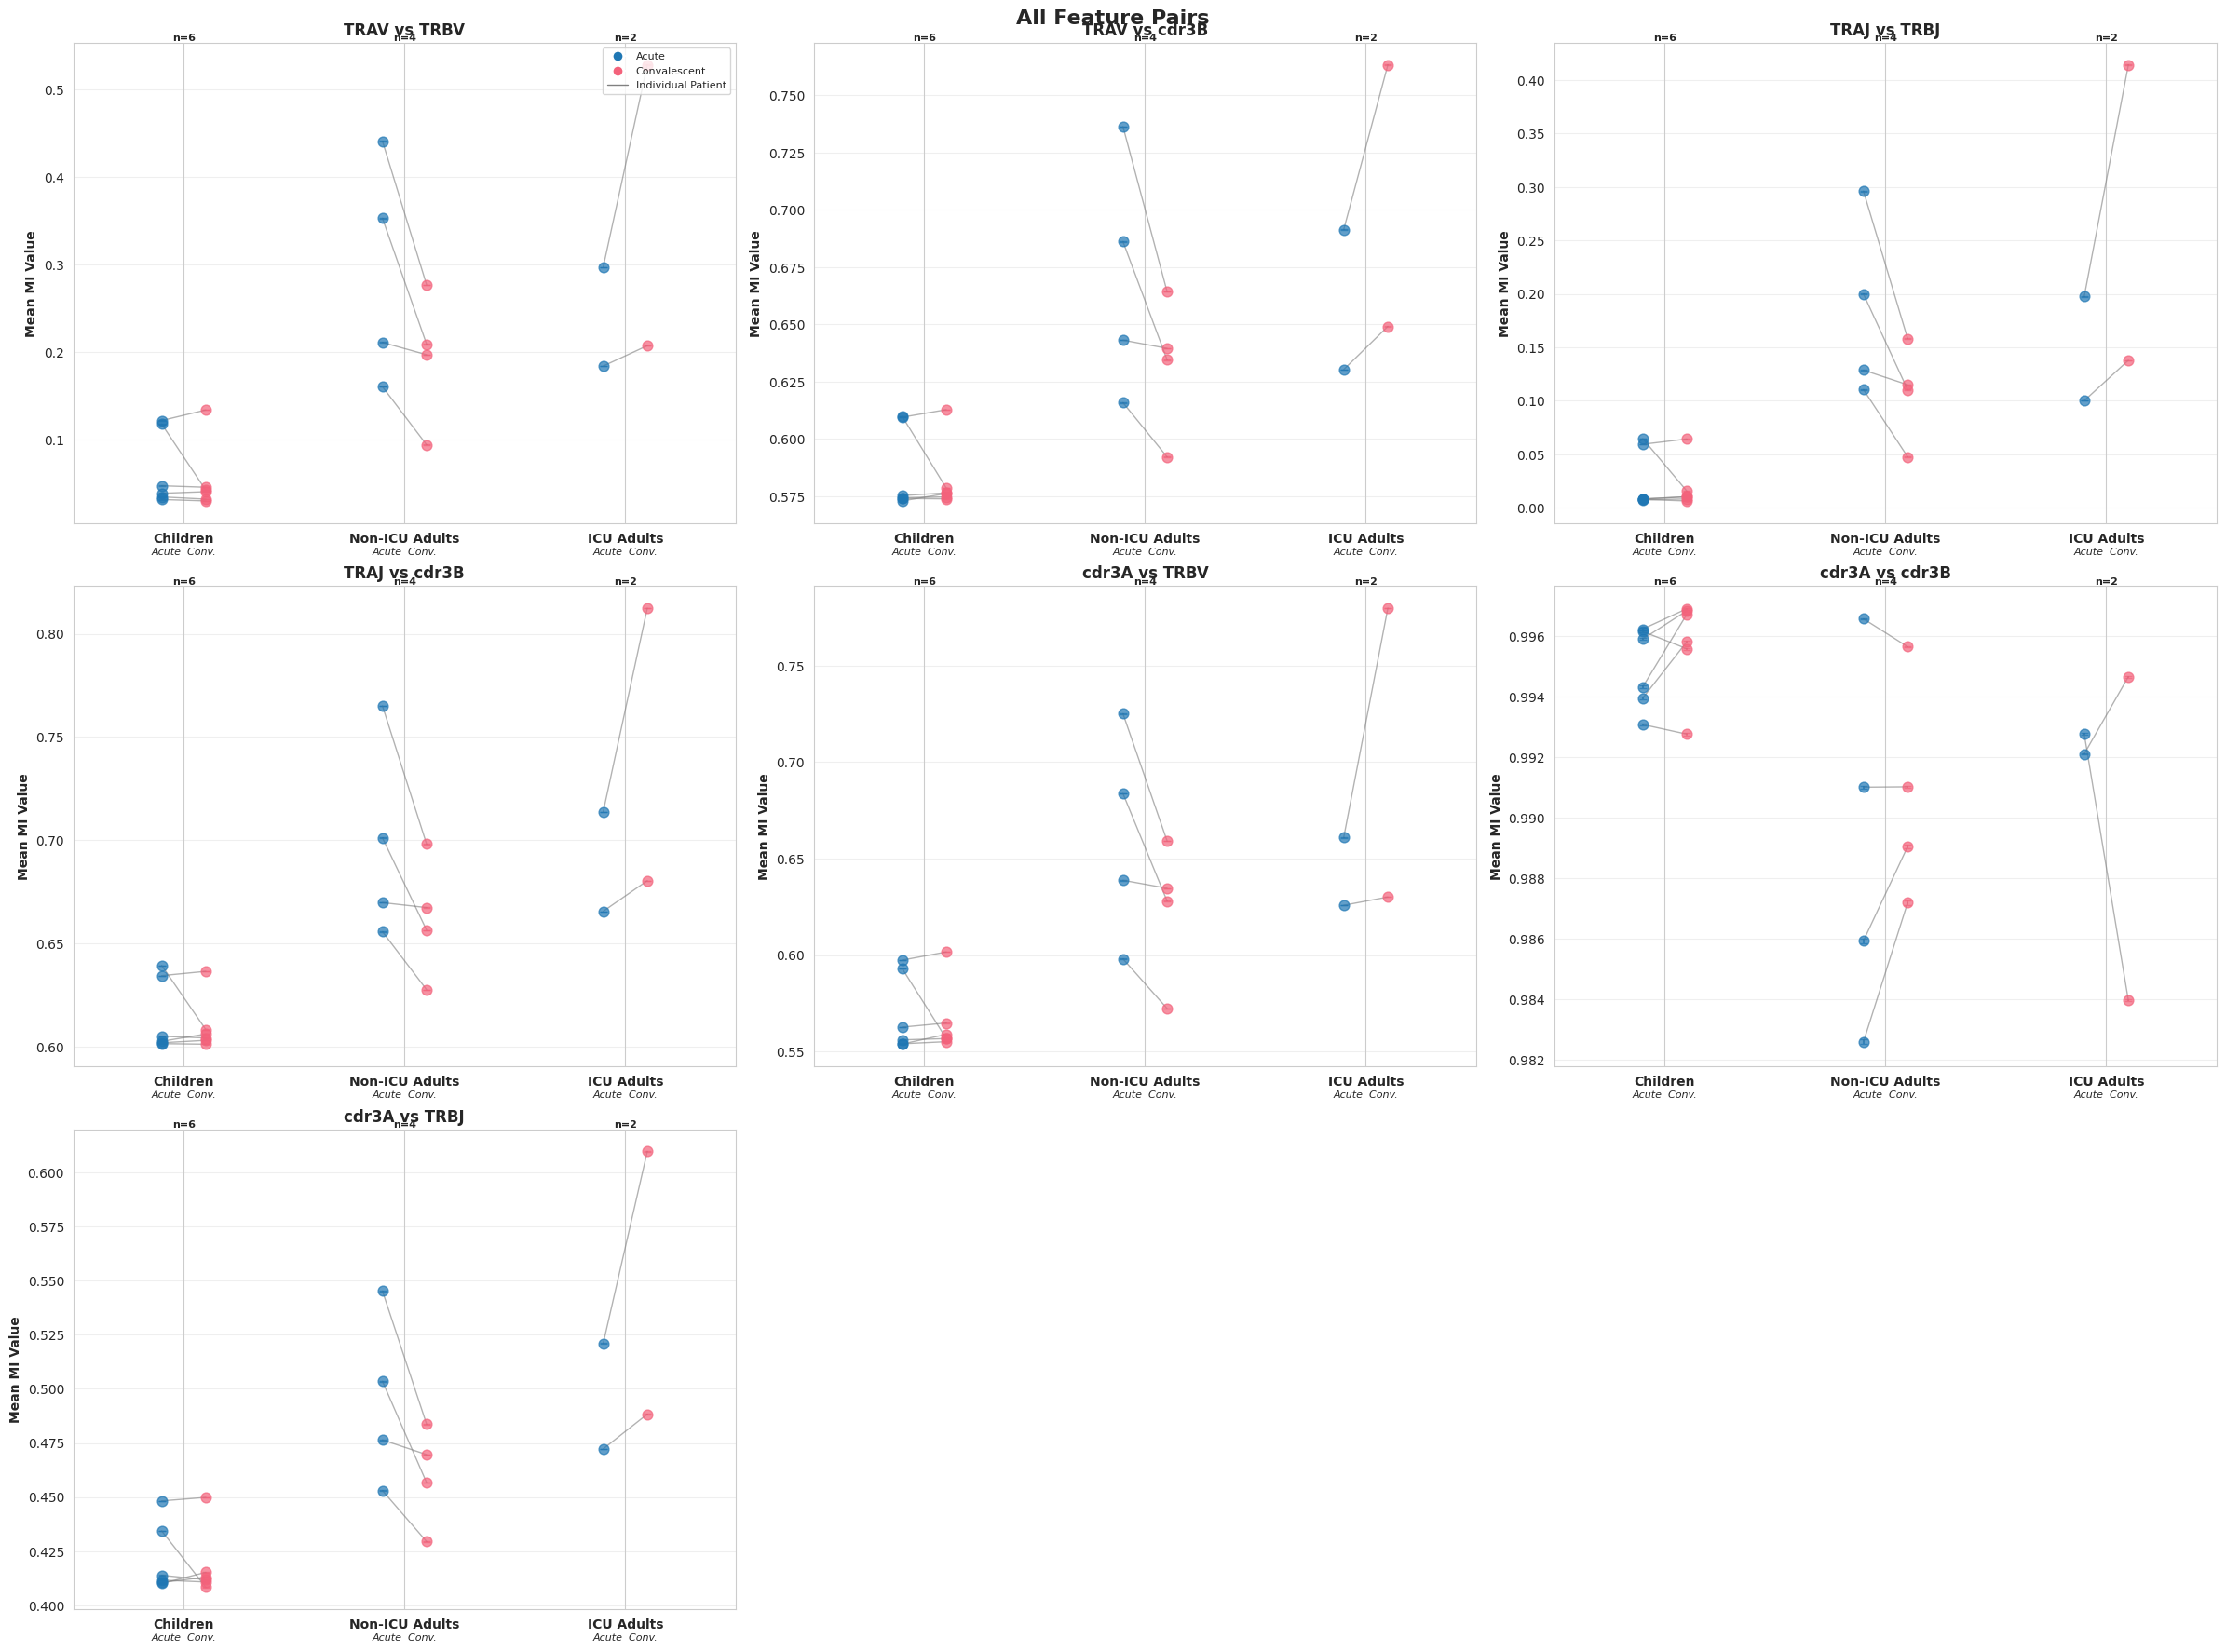

In [10]:
create_grouped_paired_plot('/mnt/d/TCRMI/results/covid_children/samples/mi.pickle',
               '/mnt/d/TCRMI/results/covid_children/samples.pickle',
               save_dir="/mnt/d/TCRMI/figures/covid_children/samples", 
               select_features=[('TRAV','TRBV'),('TRAV','cdr3B'),
                                ('cdr3A','cdr3B'), ('cdr3A','TRBV'),
                                ('cdr3A', 'TRBJ'), ('TRAJ', 'cdr3B'), ('TRAJ','TRBJ')])

# NPMI

In [11]:
F_TRBVs = tt.tr.query(contains_pattern="TRBV", functionality="F", precision="gene")
F_TRAVs = tt.tr.query(contains_pattern="TRAV", functionality="F", precision="gene")

F_TRBJs = tt.tr.query(contains_pattern="TRBJ", functionality="F", precision="gene")
F_TRAJs = tt.tr.query(contains_pattern="TRAJ", functionality="F", precision="gene")

In [12]:
def permutation_test_matrices(acute_matrices, conv_matrices, n_permutations=10000, random_state=42):
    """
    Perform permutation test comparing acute vs convalescent NPMI matrices
    
    Parameters:
    -----------
    acute_matrices: list of 2D numpy arrays (NPMI matrices from resamples)
    conv_matrices: list of 2D numpy arrays (NPMI matrices from resamples)
    n_permutations: number of permutations for the test
    random_state: random seed
    
    Returns:
    --------
    tuple: (significant_positions, p_values, observed_differences)
    """
    if len(acute_matrices) == 0 or len(conv_matrices) == 0:
        return None, None, None
    
    np.random.seed(random_state)
    
    # Stack matrices to get 3D arrays (n_resamples, n_genes1, n_genes2)
    acute_stack = np.stack(acute_matrices)
    conv_stack = np.stack(conv_matrices)
    
    # Get matrix dimensions
    n_genes1, n_genes2 = acute_stack.shape[1], acute_stack.shape[2]
    
    # Calculate observed differences (convalescent - acute) for each gene pair
    acute_means = np.mean(acute_stack, axis=0)
    conv_means = np.mean(conv_stack, axis=0)
    observed_diff = conv_means - acute_means
    
    # Initialize result arrays
    p_values = np.full((n_genes1, n_genes2), np.nan)
    significant_positions = np.zeros((n_genes1, n_genes2), dtype=bool)
    
    # Combine all values for permutation
    all_matrices = np.concatenate([acute_stack, conv_stack], axis=0)
    n_acute = len(acute_matrices)
    n_conv = len(conv_matrices)
    n_total = n_acute + n_conv
    
    # Test each gene pair position
    for i in range(n_genes1):
        for j in range(n_genes2):
            # Get values for this gene pair across all resamples
            acute_values = acute_stack[:, i, j]
            conv_values = conv_stack[:, i, j]
            all_values = all_matrices[:, i, j]
            
            # Calculate observed test statistic (difference in means)
            obs_stat = np.mean(conv_values) - np.mean(acute_values)
            
            # Permutation test
            perm_stats = []
            for _ in range(n_permutations):
                # Randomly shuffle the combined data
                shuffled_indices = np.random.permutation(n_total)
                shuffled_values = all_values[shuffled_indices]
                
                # Split into "pseudo-acute" and "pseudo-convalescent" groups
                pseudo_acute = shuffled_values[:n_acute]
                pseudo_conv = shuffled_values[n_acute:]
                
                # Calculate permuted test statistic
                perm_stat = np.mean(pseudo_conv) - np.mean(pseudo_acute)
                perm_stats.append(perm_stat)
            
            # Calculate p-value (two-tailed test)
            perm_stats = np.array(perm_stats)
            p_val = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
            p_values[i, j] = p_val
            
            # Check significance (you can adjust alpha as needed)
            if p_val < 0.05:
                significant_positions[i, j] = True
    
    return significant_positions, p_values, observed_diff

def get_patient_pairs_acute_conv(sample_ids):
    """
    Get patients with both acute and convalescent samples
    
    Returns:
    --------
    dict: {patient_id: {'acute': sample_id, 'convalescent': sample_id, 'icu_category': str}}
    """
    paired_patients = {}
    
    # Group samples by patient ID
    patient_samples = defaultdict(list)
    for sample_id in sample_ids:
        try:
            patient_id = get_patient_ID(sample_id)
            status = get_status_category(sample_id)
            icu_category = get_ICU_category(sample_id)
            
            patient_samples[patient_id].append({
                'sample_id': sample_id,
                'status': status,
                'icu_category': icu_category
            })
        except Exception as e:
            print(f"Warning: Could not process sample {sample_id}: {e}")
            continue
    
    # Find patients with both acute and convalescent samples
    for patient_id, samples in patient_samples.items():
        acute_samples = [s for s in samples if s['status'] == 'Acute']
        conv_samples = [s for s in samples if s['status'] == 'Convalescent']
        
        if len(acute_samples) > 0 and len(conv_samples) > 0:
            # Use the first sample of each type
            paired_patients[patient_id] = {
                'acute': acute_samples[0]['sample_id'],
                'convalescent': conv_samples[0]['sample_id'],
                'icu_category': acute_samples[0]['icu_category']  # Should be same for both timepoints
            }
    
    return paired_patients

def process_single_patient_feature_pair_acute_conv(patient_id, feature_pair, timepoints, sample_ids, 
                                                  sample_data, n_resamples, n_permutations):
    """
    Process a single patient-feature pair combination for acute vs convalescent
    """
    acute_sample_id = timepoints['acute']
    conv_sample_id = timepoints['convalescent']
    icu_category = timepoints['icu_category']
    
    # Find indices of acute and convalescent samples
    try:
        acute_idx = sample_ids.index(acute_sample_id)
        conv_idx = sample_ids.index(conv_sample_id)
    except ValueError as e:
        return patient_id, feature_pair, None, f"Could not find sample indices: {e}"
    
    # Collect NPMI matrices for all resamples
    acute_matrices = []
    conv_matrices = []
    
    for resample_idx in range(n_resamples):
        if resample_idx in sample_data:
            matrices = sample_data[resample_idx]
            if acute_idx < len(matrices) and conv_idx < len(matrices):
                acute_matrices.append(matrices[acute_idx])
                conv_matrices.append(matrices[conv_idx])
    
    if len(acute_matrices) == 0 or len(conv_matrices) == 0:
        return patient_id, feature_pair, None, "No matrices found"
    
    # Perform permutation test
    significant_positions, p_values, observed_diff = permutation_test_matrices(
        acute_matrices, conv_matrices, n_permutations, random_state=42
    )
    
    if significant_positions is not None:
        # Count significant changes
        significant_count = np.sum(significant_positions)
        total_tested = np.sum(~np.isnan(p_values))
        
        result = {
            'significant_count': significant_count,
            'total_tested': total_tested,
            'significant_positions': significant_positions,
            'p_values': p_values,
            'observed_differences': observed_diff,
            'acute_sample_id': acute_sample_id,
            'conv_sample_id': conv_sample_id,
            'icu_category': icu_category
        }
        return patient_id, feature_pair, result, None
    else:
        return patient_id, feature_pair, None, "Could not perform test"

def analyze_patient_npmi_changes_acute_conv(npmi_data, data_dict, n_permutations=10000, alpha=0.05, n_jobs=-1):
    """
    Analyze NPMI changes for each patient between acute and convalescent phases
    
    Parameters:
    -----------
    npmi_data: dict with feature pairs as keys
    data_dict: dict with sample data
    n_permutations: int, number of permutations for test
    alpha: float, significance level
    n_jobs: int, number of parallel jobs
    
    Returns:
    --------
    dict: {patient_id: {feature_pair: analysis_results}}
    """
    # Get sample IDs from data_dict
    sample_ids = list(data_dict.keys())
    print(f"Total samples available: {len(sample_ids)}")
    
    # Get patients with both acute and convalescent samples
    paired_patients = get_patient_pairs_acute_conv(sample_ids)
    print(f"Patients with both acute and convalescent samples: {len(paired_patients)}")
    
    # Print ICU category distribution
    icu_counts = defaultdict(int)
    for patient_id, info in paired_patients.items():
        icu_counts[info['icu_category']] += 1
    
    print("ICU category distribution:")
    for icu_cat, count in icu_counts.items():
        print(f"  {icu_cat}: {count} patients")
    
    # Prepare all tasks for parallel processing
    tasks = []
    
    for feature_pair in npmi_data.keys():
        feature1, feature2 = feature_pair
        print(f"Preparing tasks for feature pair: {feature1} vs {feature2}")
        
        # Get sample data for this feature pair
        sample_data = npmi_data[feature_pair]
        n_resamples = len(sample_data)
        
        for patient_id, timepoints in paired_patients.items():
            tasks.append((
                patient_id, feature_pair, timepoints, sample_ids, 
                sample_data, n_resamples, n_permutations
            ))
    
    print(f"Total tasks to process: {len(tasks)}")
    print(f"Running with {n_jobs} parallel jobs...")
    
    # Execute tasks in parallel
    parallel_results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(process_single_patient_feature_pair_acute_conv)(
            patient_id, feature_pair, timepoints, sample_ids,
            sample_data, n_resamples, n_permutations
        ) for patient_id, feature_pair, timepoints, sample_ids, 
             sample_data, n_resamples, n_permutations in tasks
    )
    
    # Organize results
    results = defaultdict(lambda: defaultdict(dict))
    
    for patient_id, feature_pair, result, error in parallel_results:
        if result is not None:
            results[patient_id][feature_pair] = result
        else:
            print(f"Warning: Failed to process {patient_id} - {feature_pair}: {error}")
    
    print(f"\nCompleted processing for {len(results)} patients")
    
    return results


def summarize_patient_changes(analysis_results):
    """
    Summarize significant changes across all feature pairs for each patient
    
    Returns:
    --------
    pandas.DataFrame: Summary of changes per patient
    """
    summary_data = []
    
    for patient_id, feature_results in analysis_results.items():
        total_significant = 0
        total_tested = 0
        feature_counts = {}
        
        # Get patient info from sample_mapping
        patient_info = metadata[metadata.Patient == patient_id].ICU.values[0]
        if 'Non_ICU' in patient_info and 'Adult' in patient_info:
            ICU_status = "Non-ICU Adults"
        elif 'Non' not in patient_info and 'ICU_Adult' in patient_info:
            ICU_status = "ICU Adults"
        elif "Kid" in patient_info:
            ICU_status = 'Children'
        else:
            ICU_status = patient_info
        
        for feature_pair, results in feature_results.items():
            feature_name = f"{feature_pair[0]}_{feature_pair[1]}"
            significant_count = results['significant_count']
            tested_count = results['total_tested']
            
            total_significant += significant_count
            total_tested += tested_count
            feature_counts[f"{feature_name}_significant"] = significant_count
            feature_counts[f"{feature_name}_tested"] = tested_count
            feature_counts[f"{feature_name}_percentage"] = (significant_count / tested_count * 100) if tested_count > 0 else 0
        
        summary_row = {
            'Patient_ID': patient_id,
            'Total_Significant_Changes': total_significant,
            'Total_Gene_Pairs_Tested': total_tested,
            'Overall_Percentage_Changed': (total_significant / total_tested * 100) if total_tested > 0 else 0,
            'ICU_Status': ICU_status,
            **feature_counts
        }
        
        summary_data.append(summary_row)
    
    return pd.DataFrame(summary_data)

def save_results(analysis_results, summary_df, output_dir):
    """Save analysis results"""
    os.makedirs(output_dir, exist_ok=True)
    
    # Convert defaultdict to regular dict for pickling
    regular_dict_results = {}
    for patient_id, feature_results in analysis_results.items():
        regular_dict_results[patient_id] = dict(feature_results)
    
    # Save detailed results
    with open(os.path.join(output_dir, 'sample_npmi_changes_detailed.pickle'), 'wb') as f:
        pickle.dump(regular_dict_results, f)
    
    # Save summary
    summary_df.to_csv(os.path.join(output_dir, 'sample_npmi_changes_summary.csv'), index=False)
    

def create_radial_column_chart(summary_df, selected_column, save_path=None):
    """
    Create a radial column chart showingselected_columnfor each patient,
    colored by ICU_Status
    
    Parameters:
    -----------
    summary_df: pandas.DataFrame with columns Patient_ID,selected_column ICU_Status
    save_path: str, optional path to save the figure
    """
    
    # Check if required columns exist
    required_cols = ['Patient_ID', selected_column, 'ICU_Status']
    missing_cols = [col for col in required_cols if col not in summary_df.columns]
    if missing_cols:
        print(f"Warning: Missing columns {missing_cols}. Available columns: {list(summary_df.columns)}")
        # Try alternative column names
        if 'ICU_Category' in summary_df.columns:
            summary_df = summary_df.rename(columns={'ICU_Category': 'ICU_Status'})
        else:
            print("Cannot find ICU status column")
            return
    
    # Filter out any rows with missing data
    df_clean = summary_df.dropna(subset=[selected_column, 'ICU_Status'])
    
    if len(df_clean) == 0:
        print("No valid data found for plotting")
        return
    
    # Set up colors for ICU categories
    icu_categories = df_clean['ICU_Status'].unique()
    colors = {
        'Children': '#2E8B57',           # Sea Green
        'Non-ICU Adults': '#4169E1',     # Royal Blue
        'ICU Adults': '#DC143C'          # Crimson
    }
    
    # Assign colors, use default if category not in predefined colors
    default_colors = plt.cm.Set3(np.linspace(0, 1, len(icu_categories)))
    for i, cat in enumerate(icu_categories):
        if cat not in colors:
            colors[cat] = default_colors[i]
    
    # Create figure and polar axis
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    # Calculate angles for each patient
    n_patients = len(df_clean)
    angles = np.linspace(0, 2 * np.pi, n_patients, endpoint=False)
    
    # Get values and colors for each patient
    values = df_clean[selected_column].values
    patient_colors = [colors[status] for status in df_clean['ICU_Status'].values]
    patient_ids = df_clean['Patient_ID'].values
    
    # Create the radial bars
    bars = ax.bar(angles, values, width=2*np.pi/n_patients*0.8, 
                  color=patient_colors, alpha=0.8, edgecolor='white', linewidth=1)
    
    # Customize the plot
    ax.set_theta_zero_location('N')  # Start from top
    ax.set_theta_direction(-1)       # Clockwise
    
    # Set radial limits
    max_val = values.max()
    ax.set_ylim(0, max_val * 1.1)
    
    # Add patient labels around the circle
    for angle, patient_id in zip(angles, patient_ids):
        # Calculate label position (slightly outside the circle)
        label_radius = max_val * 1.15
        ax.text(angle, label_radius, patient_id, 
                rotation=np.degrees(angle) - 90 if angle < np.pi else np.degrees(angle) + 90,
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Add radial grid lines and labels
    ax.set_rticks(np.linspace(0, max_val, 6))
    ax.set_rlabel_position(0)
    ax.tick_params(axis='y', labelsize=10)
    
    # Create legend
    legend_elements = []
    for icu_status in icu_categories:
        count = len(df_clean[df_clean['ICU_Status'] == icu_status])
        legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[icu_status], 
                                           label=f'{icu_status} (n={count})'))
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    # Add title
    plt.title('Percentage Changes by Patient\n(Convalescent vs Acute)', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Add subtitle with statistics
    mean_val = values.mean()
    std_val = values.std()
    plt.figtext(0.5, 0.02, f'Mean: {mean_val:.1f}% ± {std_val:.1f}% (SD)', 
                ha='center', fontsize=12, style='italic')
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', transparent=True)
        print(f"Figure saved to: {save_path}")
    
    plt.tight_layout()


In [13]:
npmi_data = pd.read_pickle("/mnt/d/TCRMI/results/covid_children/samples/npmi.pickle")
data_dict = pd.read_pickle("/mnt/d/TCRMI/results/covid_children/samples.pickle")

In [15]:
results = analyze_patient_npmi_changes_acute_conv(
    npmi_data, data_dict, n_permutations=10000, n_jobs=-1
)
summary_df = summarize_patient_changes(results)

Total samples available: 24
Patients with both acute and convalescent samples: 12
ICU category distribution:
  ICU Adults: 2 patients
  Children: 6 patients
  Non-ICU Adults: 4 patients
Preparing tasks for feature pair: TRAV vs TRBV
Preparing tasks for feature pair: TRAJ vs TRBJ
Total tasks to process: 24
Running with -1 parallel jobs...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of  24 | elapsed: 19.6min finished



Completed processing for 12 patients


In [16]:
summary_df = summarize_patient_changes(results)
summary_df.head()

,Patient_ID,Total_Significant_Changes,Total_Gene_Pairs_Tested,Overall_Percentage_Changed,ICU_Status,TRAV_TRBV_significant,TRAV_TRBV_tested,TRAV_TRBV_percentage,TRAJ_TRBJ_significant,TRAJ_TRBJ_tested,TRAJ_TRBJ_percentage
0,COV_001,1642,2823,58.165073,ICU Adults,1285,2160,59.490741,357,663,53.846154
1,COV_002,1712,2823,60.644704,ICU Adults,1318,2160,61.018519,394,663,59.426848
2,COV_007,987,2823,34.962806,Children,730,2160,33.796296,257,663,38.763198
3,COV_009,678,2823,24.017003,Non-ICU Adults,541,2160,25.046296,137,663,20.663650
4,COV_010,920,2823,32.589444,Children,707,2160,32.731481,213,663,32.126697


In [17]:
save_results(results, summary_df, "/mnt/d/TCRMI/results/CTL/samples")

Figure saved to: /mnt/d/TCRMI/results/CTL/samples/radial_TRAJ_TRBJ.pdf


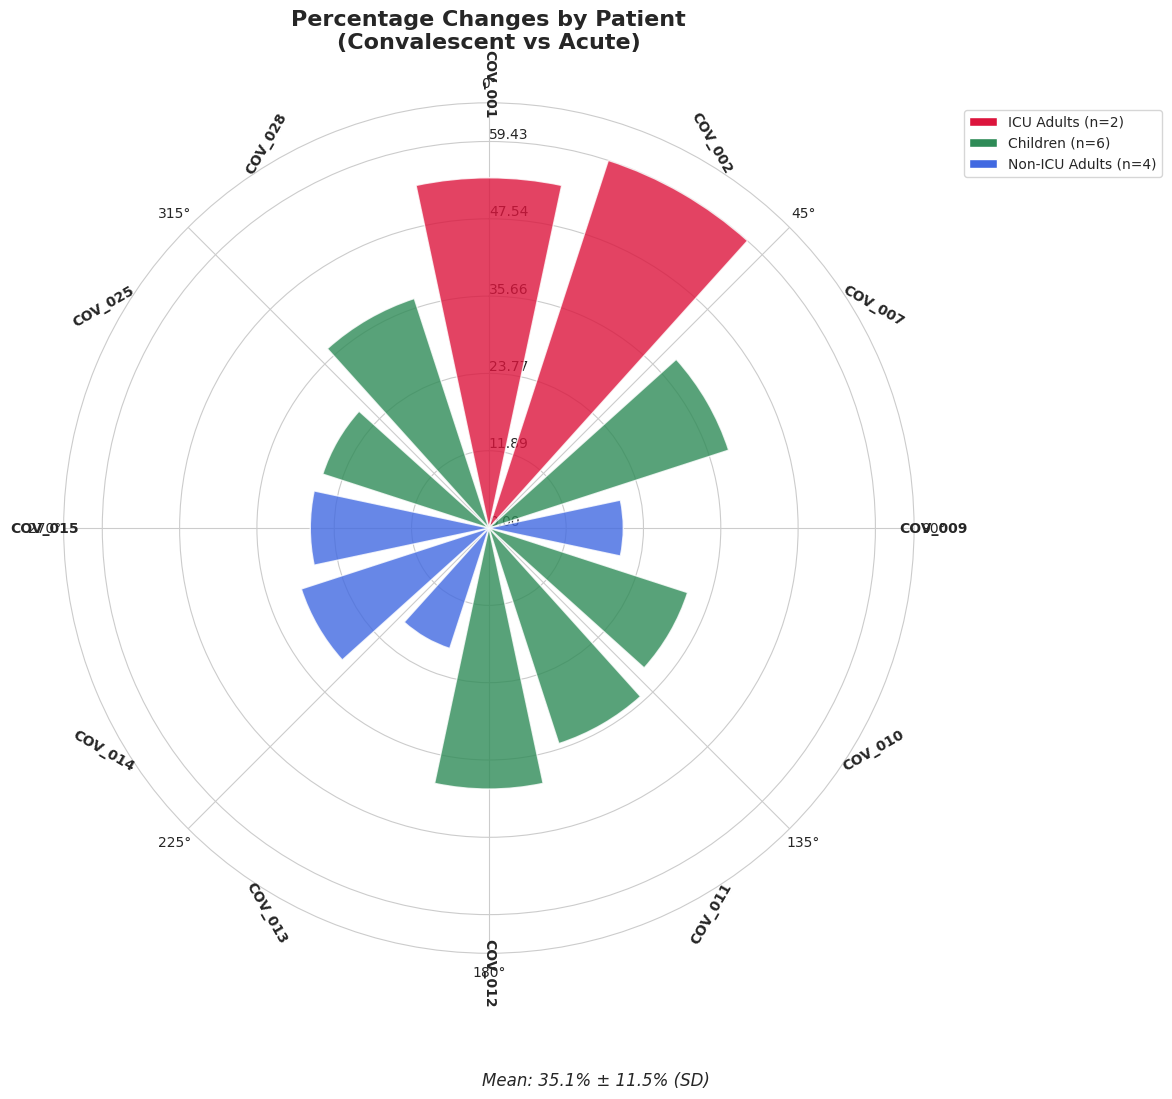

In [ ]:
create_radial_column_chart(summary_df, 'TRAJ_TRBJ_percentage', save_path='/mnt/d/TCRMI/results/covid_children/samples/radial_TRAJ_TRBJ.pdf')

In [ ]:
create_radial_column_chart(summary_df, save_path='/mnt/d/TCRMI/results/CTL/samples/radial_TRAV_TRBV.pdf')